Using `scripts.kz2d.generate_data.py` we've generated a lot of data, and using BU's super-computing cluster I have trained a neural network to predict the final field values of the 2D $\phi^4$ model.

The model we use is a U-net model. These are very popular for analyzing image data, or spatially correlated data. Unets are useful because they allow the model to learn about features on different length scales. 




![U-Net](../figures/2d/unet_diagram.png)

Roughly, a UNET works by running a filter over the image. This filter has trainable parameters in it, and can be thought of as a "feature selector". For instance, this filter might distinguish only edges in an image, or it might blur the image to only look at the "broad strokes". The output of this filter is a number, which assigned to each pixel. Then we downsample the image, which means we reduce its size by using `MaxPool`. Then we run another filter over it, which produces more numbers, which we downsample again and so on. Afterwards, we upsample using skip connections. 

In [ ]:
import torch
import src.kz_ml as kzml

# ---- inputs ----
N = 256                                     # lattice size of the v2 data

model  = kzml.UNet()
blocks = ["down1", "down2", "down3", "bottom", "up3", "up2", "up1", "out"]

# record each block's output shape with forward hooks
shapes = {}
for name in blocks:
    getattr(model, name).register_forward_hook(
        lambda mod, inp, out, name=name: shapes.__setitem__(name, tuple(out.shape[1:])))

with torch.no_grad():
    y = model(torch.zeros(1, 1, N, N))      # one dummy input field

print(f"{'block':<8} {'output (channels, H, W)':<26} {'params':>10}")
print("-" * 46)
for name in blocks:
    n_par = sum(p.numel() for p in getattr(model, name).parameters())
    note  = "   <- + skip from " + {"up3": "down3", "up2": "down2", "up1": "down1"}[name] \
            if name in ("up3", "up2", "up1") else ""
    print(f"{name:<8} {str(shapes[name]):<26} {n_par:>10,}{note}")
print("-" * 46)
print(f"{'total':<35} {sum(p.numel() for p in model.parameters()):>10,}")
print(f"\ninput (1, {N}, {N})  ->  output {tuple(y.shape[1:])}: one logit per site (>0 = predict +)")

I decided to use three downsamplings and three upsamplings. If the image was very larg you might consider perhaps downsampling more. 


In [1]:
import sys; sys.path.insert(0, "..")
import os
import json

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
import torch

import src.analysis as an
import src.kz_ml as kzml

tau=   8  best sigma/xi_hat: 2.72  2.52  2.31  2.11  1.98  2.16  1.84  1.34
tau=  16  best sigma/xi_hat: 2.86  2.65  2.42  2.22  2.39  2.25  1.86  1.37
tau=  32  best sigma/xi_hat: 2.97  2.75  2.52  2.28  2.52  2.25  1.88  1.37
tau=  64  best sigma/xi_hat: 3.05  2.79  2.55  2.33  2.55  2.28  1.91  1.37
tau= 128  best sigma/xi_hat: 3.16  2.93  2.65  2.55  2.58  2.31  1.91  1.39
tau= 256  best sigma/xi_hat: 3.16  2.86  2.58  2.58  2.62  2.31  1.93  1.39


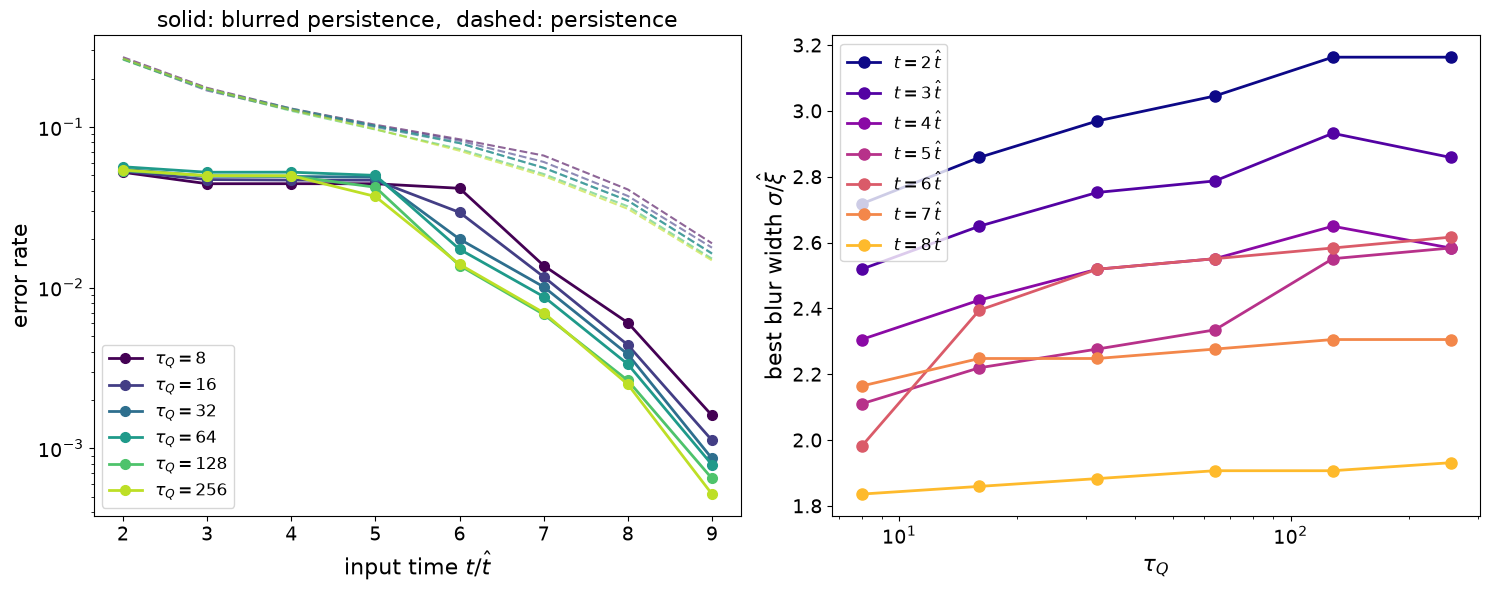

In [34]:
# ---- inputs ----
TAUS     = [8, 16, 32, 64, 128, 256]
T_LIST   = [2, 3, 4, 5, 6, 7, 8, 9]            # input times, units of t_hat
SIG_XI   = np.geomspace(1.0, 3.5, 100)         # blur widths sigma, units of xi_hat
T_SHOW   = [2, 3, 4, 5, 6, 7, 8]               # times shown in the right panel
TARGET   = "y_end"
FONTSIZE = 16

blur_t = list(T_LIST)                          # times this scan was run at (used by later cells)
pers_err, blur_err, blur_sig = {}, {}, {}      # kept for comparison with the U-Net later
for tau in TAUS:
    d = an.load_chunk(tau, chunk=0)
    Y = d[TARGET]
    N, dx, xi_hat = int(d["N"]), float(d["dx"]), float(d["xi_hat"])

    kx = 2 * np.pi * np.fft.fftfreq(N, d=dx)
    ky = 2 * np.pi * np.fft.rfftfreq(N, d=dx)
    K2 = kx[:, None]**2 + ky[None, :]**2

    pers_err[tau], blur_err[tau], blur_sig[tau] = [], [], []
    for t in blur_t:
        X, _ = an.snapshot_at(d, t)
        F = np.fft.rfft2(X, axes=(-2, -1))
        errs = []
        for m in SIG_XI:
            sigma = m * xi_hat                                   # physical units
            Xb = np.fft.irfft2(F * np.exp(-K2 * sigma**2 / 2), s=(N, N), axes=(-2, -1))
            errs.append(((Xb > 0) != Y).mean())
        j = int(np.argmin(errs))
        if j in (0, len(SIG_XI) - 1):
            print(f"  warning: tau={tau} t={t} best sigma at edge of search range")
        pers_err[tau].append(((X > 0) != Y).mean())
        blur_err[tau].append(errs[j])
        blur_sig[tau].append(SIG_XI[j])
    print(f"tau={tau:4d}  best sigma/xi_hat: " + "  ".join(f"{s:.2f}" for s in blur_sig[tau]))

# ---- plot ----
colors = plt.cm.viridis(np.linspace(0, 0.9, len(TAUS)))
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

for tau, c in zip(TAUS, colors):
    ax[0].semilogy(blur_t, pers_err[tau], "--", color=c, lw=1.5, alpha=0.6)
    ax[0].semilogy(blur_t, blur_err[tau], "o-", color=c, ms=7, lw=2, label=rf"$\tau_Q = {tau}$")
ax[0].set_xlabel(r"input time $t/\hat t$", fontsize=FONTSIZE)
ax[0].set_ylabel("error rate", fontsize=FONTSIZE)
ax[0].set_title("solid: blurred persistence,  dashed: persistence", fontsize=FONTSIZE)

pcolors = plt.cm.plasma(np.linspace(0, 0.85, len(T_SHOW)))
for t, c in zip(T_SHOW, pcolors):
    j = blur_t.index(t)
    ax[1].plot(TAUS, [blur_sig[tau][j] for tau in TAUS], "o-", color=c, ms=8, lw=2,
               label=rf"$t = {t}\,\hat t$")
ax[1].set_xscale("log")
ax[1].set_xlabel(r"$\tau_Q$", fontsize=FONTSIZE)
ax[1].set_ylabel(r"best blur width $\sigma/\hat\xi$", fontsize=FONTSIZE)

for a in ax:
    a.tick_params(labelsize=FONTSIZE - 2)
    a.legend(fontsize=FONTSIZE - 4)
plt.tight_layout()
plt.savefig("../figures/2d/blurred_persistence.png", dpi=150)
plt.show()

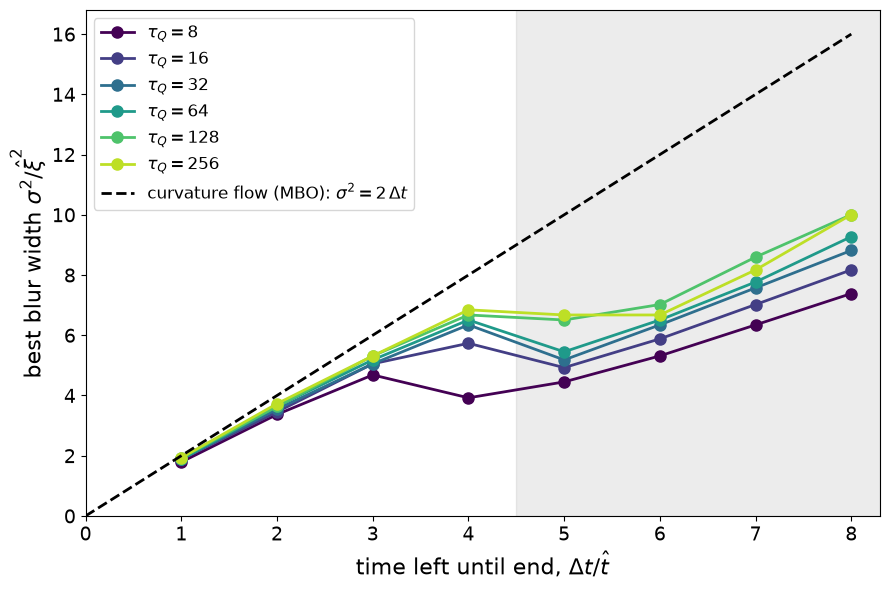

In [36]:
# ---- inputs ----
T_END    = 10.0                         # end of run, units of t_hat
T_FORM   = 5.5                          # approximate formation time, units of t_hat
FONTSIZE = 16

colors = plt.cm.viridis(np.linspace(0, 0.9, len(TAUS)))
fig, ax = plt.subplots(figsize=(9, 6))

remaining = T_END - np.array(blur_t)    # time left until end, units of t_hat
for tau, c in zip(TAUS, colors):
    ax.plot(remaining, np.array(blur_sig[tau])**2, "o-", color=c, ms=8, lw=2, label=rf"$\tau_Q = {tau}$")

dd = np.linspace(0, remaining.max(), 50)
ax.plot(dd, 2 * dd, "k--", lw=2, label=r"curvature flow (MBO): $\sigma^2 = 2\,\Delta t$")
ax.axvspan(T_END - T_FORM, remaining.max() + 0.3, color="grey", alpha=0.15)   # snapshot before formation

ax.set_xlim(0, remaining.max() + 0.3)
ax.set_ylim(0, None)
ax.set_xlabel(r"time left until end, $\Delta t/\hat t$", fontsize=FONTSIZE)
ax.set_ylabel(r"best blur width $\sigma^2/\hat\xi^2$", fontsize=FONTSIZE)
ax.tick_params(labelsize=FONTSIZE - 2)
ax.legend(fontsize=FONTSIZE - 4)
plt.tight_layout()
plt.savefig("../figures/2d/blur_vs_curvature_flow.png", dpi=150)
plt.show()

Look up: The blur-and-threshold trick (the math side):

MBO scheme, after Merriman, Bence & Osher. Also called threshold dynamics or diffusion-generated motion by mean curvature.

model A dynamics
KIBBLE ZUREK COarsening

# Part 2

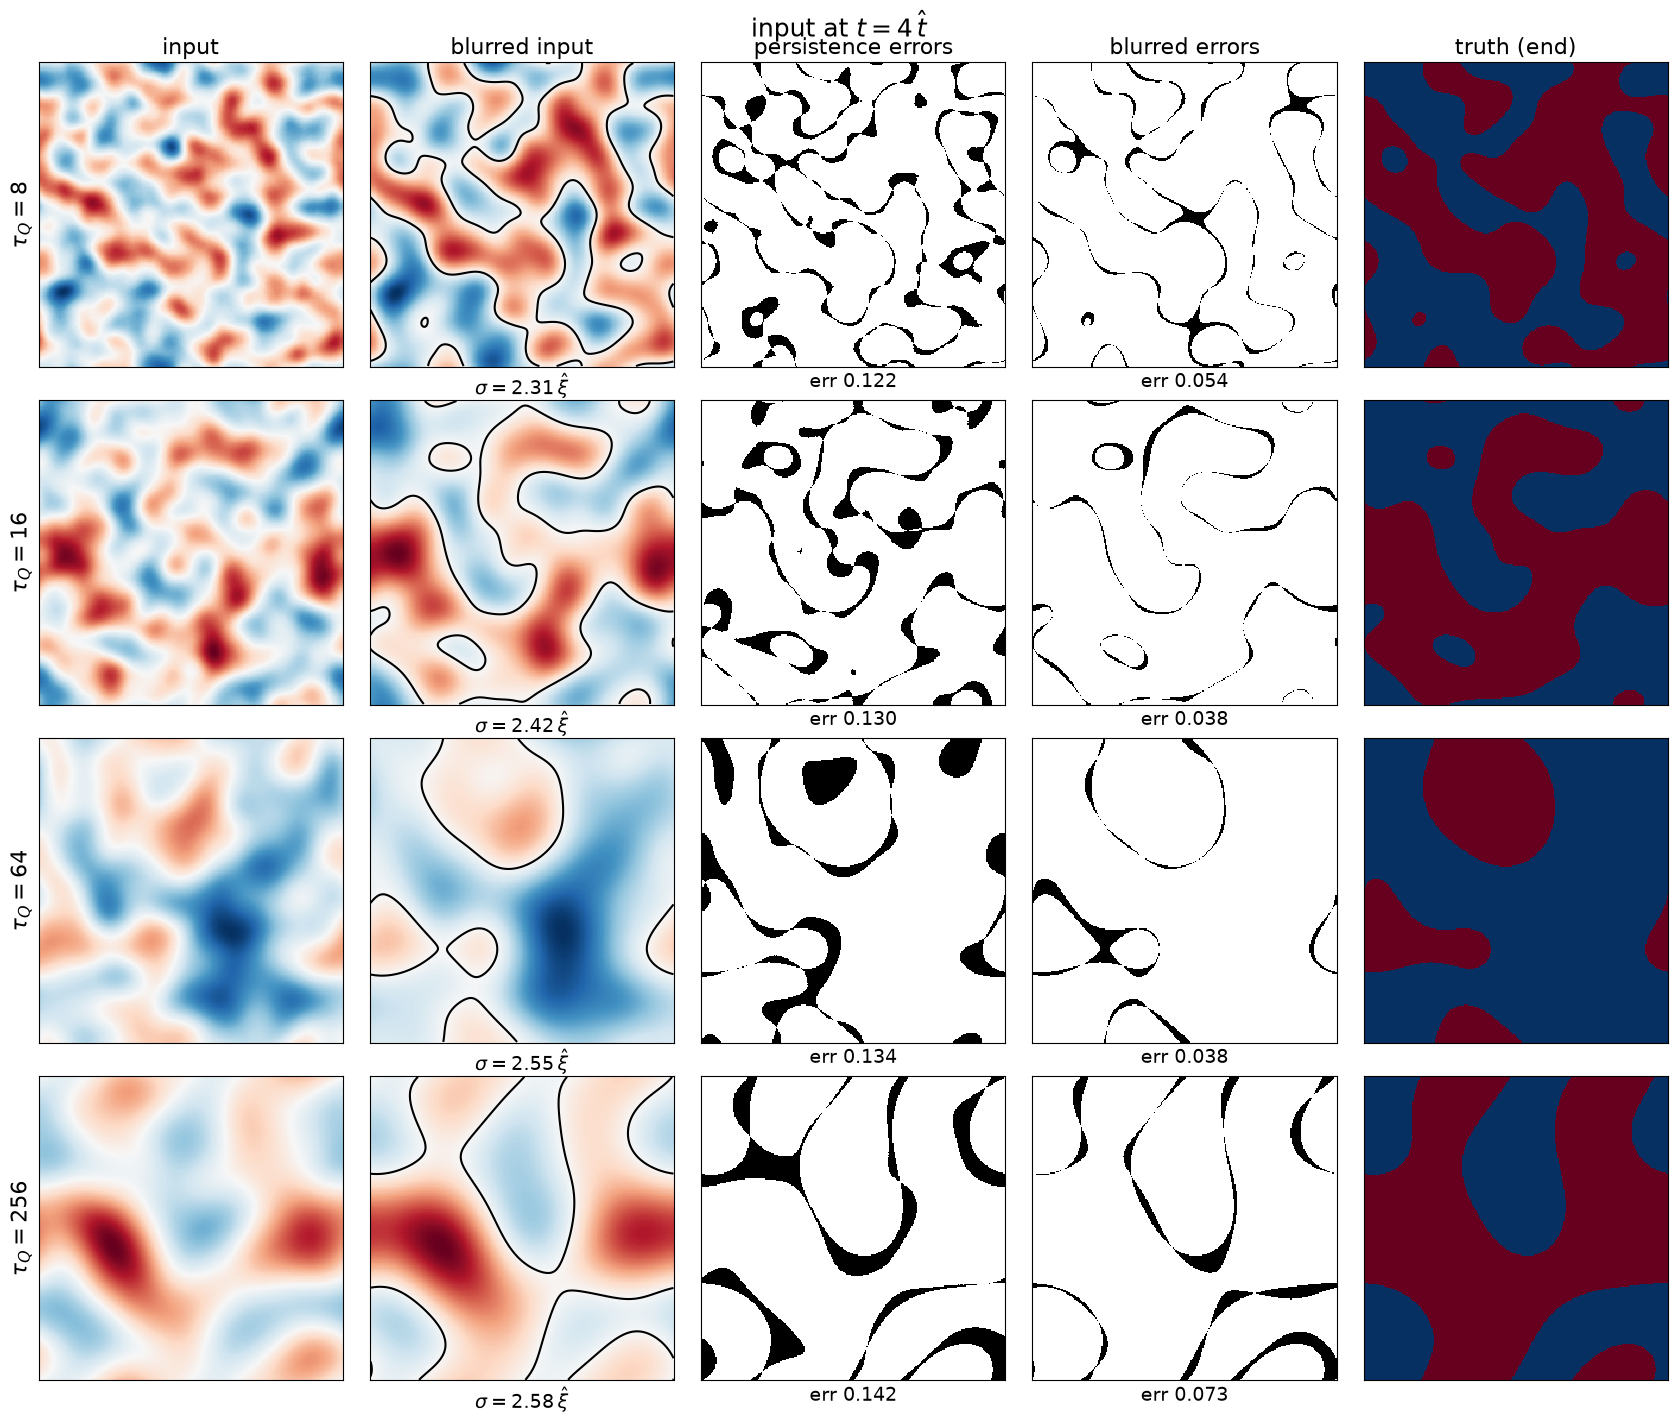

In [16]:
# ---- inputs ----
TAUS_SHOW = [8,16, 64, 256]
T_IN      = 4                                  # must be one of T_LIST from the scan cell
SAMPLE    = 0                                   # no training involved, so any sample is fine
TARGET    = "y_end"
FONTSIZE  = 16

cols = ["input", "blurred input", "persistence errors", "blurred errors", "truth (end)"]
fig, axes = plt.subplots(len(TAUS_SHOW), len(cols),
                         figsize=(3.4 * len(cols), 3.6 * len(TAUS_SHOW)), squeeze=False)

for row, tau in enumerate(TAUS_SHOW):
    d = an.load_chunk(tau, chunk=0)
    N, dx, xi_hat = int(d["N"]), float(d["dx"]), float(d["xi_hat"])
    X, t_used = an.snapshot_at(d, T_IN)
    x, Y = X[SAMPLE], d[TARGET][SAMPLE]

    # blur at this tau's best sigma from the scan
    m  = blur_sig[tau][T_LIST.index(T_IN)]
    kx = 2 * np.pi * np.fft.fftfreq(N, d=dx)
    ky = 2 * np.pi * np.fft.rfftfreq(N, d=dx)
    K2 = kx[:, None]**2 + ky[None, :]**2
    xb = np.fft.irfft2(np.fft.rfft2(x) * np.exp(-K2 * (m * xi_hat)**2 / 2), s=(N, N))

    v, vb = np.abs(x).max(), np.abs(xb).max()
    axes[row, 0].imshow(x,  cmap="RdBu_r", vmin=-v,  vmax=v,  interpolation="nearest")
    axes[row, 1].imshow(xb, cmap="RdBu_r", vmin=-vb, vmax=vb, interpolation="nearest")
    axes[row, 1].contour(xb, levels=[0], colors="k", linewidths=1.5)
    axes[row, 2].imshow((x > 0) != Y,  cmap="Greys", vmin=0, vmax=1, interpolation="nearest")
    axes[row, 3].imshow((xb > 0) != Y, cmap="Greys", vmin=0, vmax=1, interpolation="nearest")
    axes[row, 4].imshow(Y, cmap="RdBu_r", vmin=0, vmax=1, interpolation="nearest")

    axes[row, 0].set_ylabel(rf"$\tau_Q = {tau}$", fontsize=FONTSIZE)
    axes[row, 1].set_xlabel(rf"$\sigma = {m:.2f}\,\hat\xi$", fontsize=FONTSIZE - 2)
    axes[row, 2].set_xlabel(f"err {((x > 0) != Y).mean():.3f}", fontsize=FONTSIZE - 2)
    axes[row, 3].set_xlabel(f"err {((xb > 0) != Y).mean():.3f}", fontsize=FONTSIZE - 2)

for col, lab in enumerate(cols):
    axes[0, col].set_title(lab, fontsize=FONTSIZE)
for ax in axes.ravel():
    ax.set_xticks([]); ax.set_yticks([])

fig.suptitle(rf"input at $t = {t_used:g}\,\hat t$", fontsize=FONTSIZE + 2)
plt.tight_layout()
plt.savefig(f"../figures/2d/blur_samples_t{T_IN}.png", dpi=150)
plt.show()

test samples in chunk 0: [12 20 41]   showing sample 12


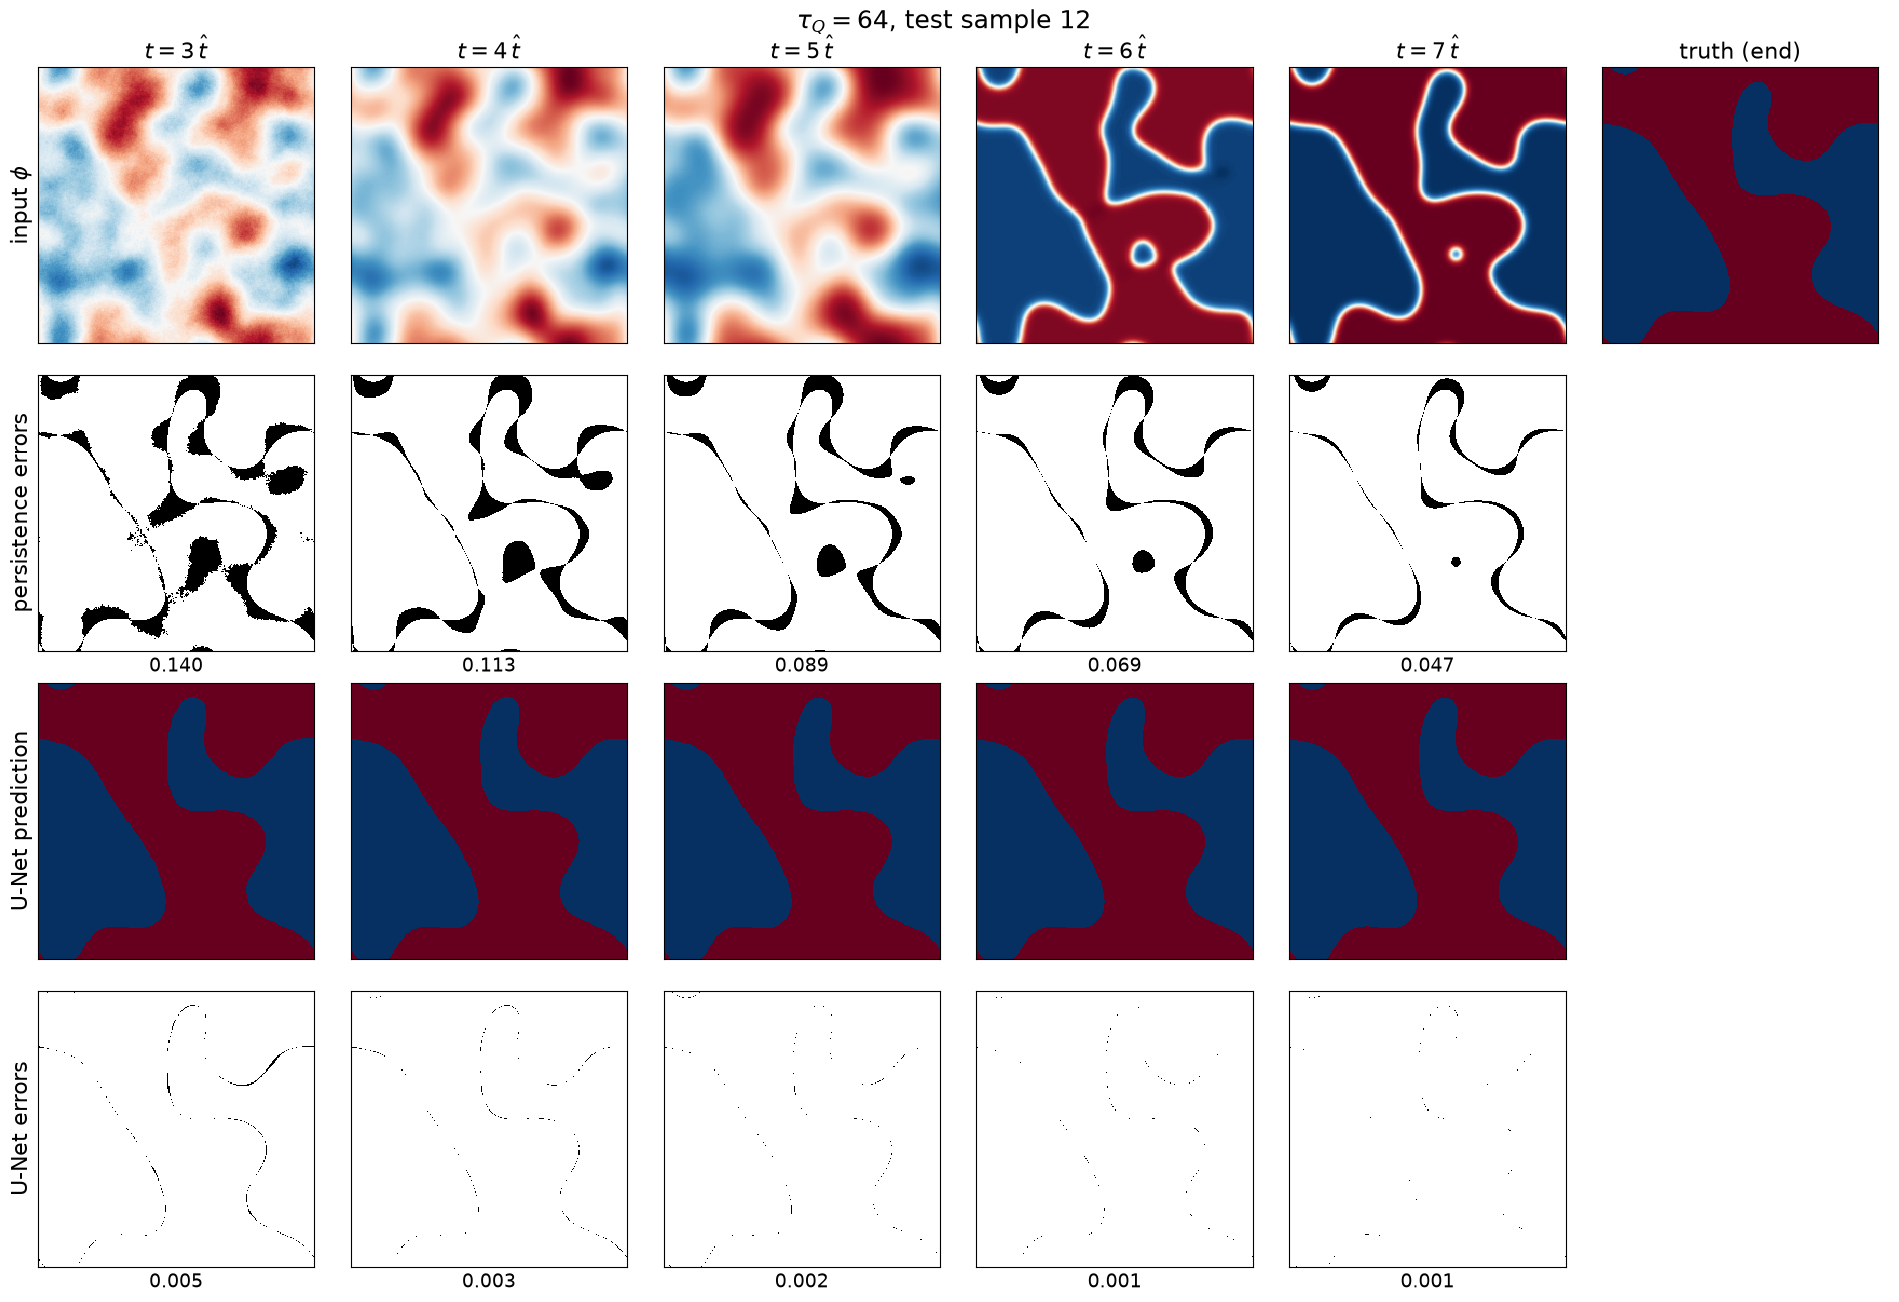

In [37]:
# ---- inputs ----
TAU      = 64
T_LIST   = [3, 4, 5, 6, 7]        # input times, units of t_hat
TARGET   = "y_end"
PICK     = 0                      # which test sample from chunk 0 to show
SEED     = 0                      # split seed used in training
FONTSIZE = 16

# ---- find test-split samples inside chunk 0 (same split as kz_ml.make_loaders) ----
n_total  = an.load_results(TAU, target=TARGET)[0]["n_samples"]
perm     = np.random.default_rng(SEED).permutation(n_total)
test_idx = perm[: n_total // 10]
d        = an.load_chunk(TAU, chunk=0)
n_chunk  = len(d["y_end"])
test_in_chunk = np.sort(test_idx[test_idx < n_chunk])     # chunk 0 = samples 0..n_chunk-1
s = int(test_in_chunk[PICK])
print(f"test samples in chunk 0: {test_in_chunk}   showing sample {s}")

Y = d[TARGET][s]

# ---- plot: columns = input times, last column = truth ----
rows = ["input $\\phi$", "persistence errors", "U-Net prediction", "U-Net errors"]
fig, axes = plt.subplots(len(rows), len(T_LIST) + 1,
                         figsize=(3.2 * (len(T_LIST) + 1), 3.3 * len(rows)), squeeze=False)

for col, t in enumerate(T_LIST):
    tag = os.path.join(an.RESULTS, f"tau{TAU}_that{t:g}_{TARGET}")
    model, meta = an.load_model(tag)
    X, t_used = an.snapshot_at(d, t)
    x    = X[s]
    pred = an.predict(model, X[[s]], meta["scale"])[0]
    pers = x > 0

    v = np.abs(x).max()
    axes[0, col].imshow(x, cmap="RdBu_r", vmin=-v, vmax=v, interpolation="nearest")
    axes[1, col].imshow(pers != Y, cmap="Greys", vmin=0, vmax=1, interpolation="nearest")
    axes[2, col].imshow(pred, cmap="RdBu_r", vmin=0, vmax=1, interpolation="nearest")
    axes[3, col].imshow(pred != Y, cmap="Greys", vmin=0, vmax=1, interpolation="nearest")

    axes[0, col].set_title(rf"$t = {t_used:g}\,\hat t$", fontsize=FONTSIZE)
    axes[1, col].set_xlabel(f"{(pers != Y).mean():.3f}", fontsize=FONTSIZE - 2)
    axes[3, col].set_xlabel(f"{(pred != Y).mean():.3f}", fontsize=FONTSIZE - 2)

# truth column
axes[0, -1].imshow(Y, cmap="RdBu_r", vmin=0, vmax=1, interpolation="nearest")
axes[0, -1].set_title("truth (end)", fontsize=FONTSIZE)
for r in range(1, len(rows)):
    axes[r, -1].axis("off")

for r, lab in enumerate(rows):
    axes[r, 0].set_ylabel(lab, fontsize=FONTSIZE)
for ax in axes.ravel():
    ax.set_xticks([]); ax.set_yticks([])

fig.suptitle(rf"$\tau_Q = {TAU}$, test sample {s}", fontsize=FONTSIZE + 2)
plt.tight_layout()
plt.savefig(f"../figures/2d/predictions_tau{TAU}.png", dpi=150)
plt.show()

test samples in chunk 0: [12 20 41]   showing sample 12


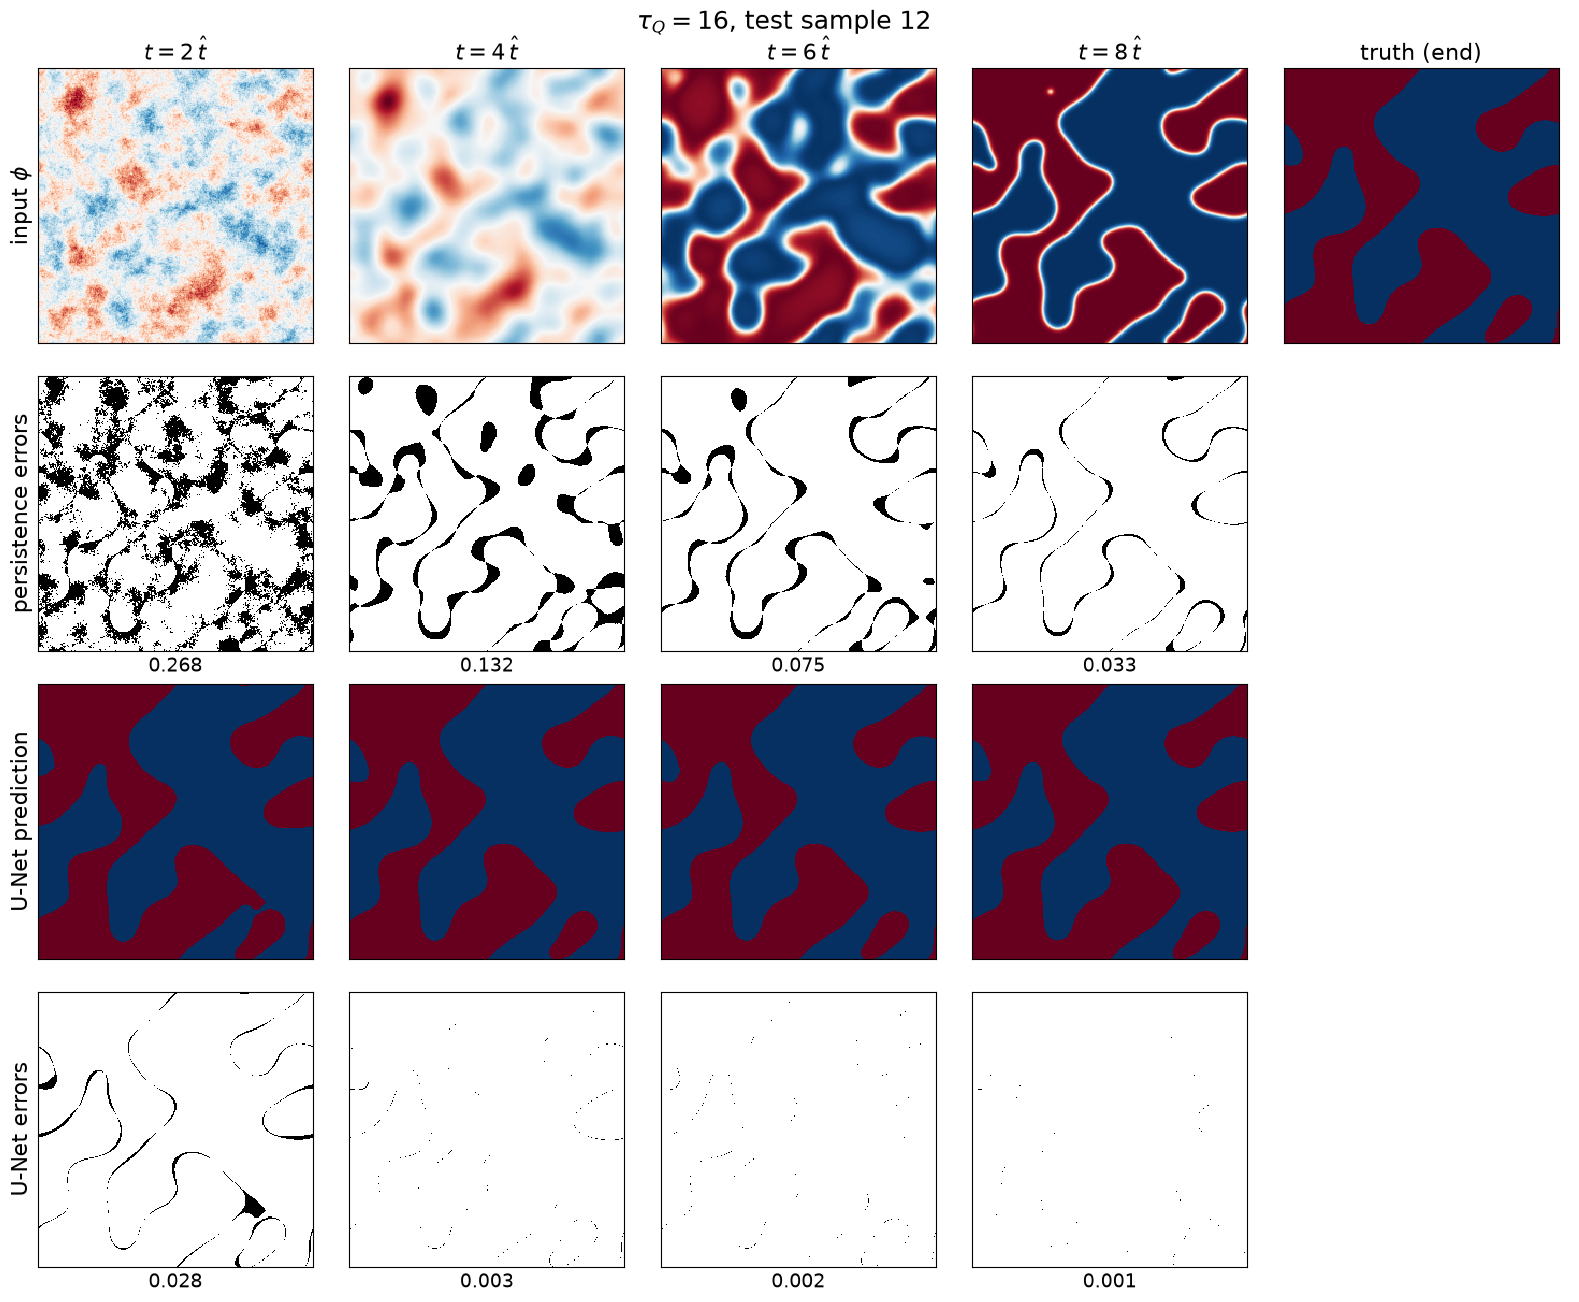

In [38]:
# ---- inputs ----
TAU      = 16
T_LIST   = [2,4,6,8]        # input times, units of t_hat
TARGET   = "y_end"
PICK     = 0                      # which test sample from chunk 0 to show
SEED     = 0                      # split seed used in training
FONTSIZE = 16

# ---- find test-split samples inside chunk 0 (same split as kz_ml.make_loaders) ----
n_total  = an.load_results(TAU, target=TARGET)[0]["n_samples"]
perm     = np.random.default_rng(SEED).permutation(n_total)
test_idx = perm[: n_total // 10]
d        = an.load_chunk(TAU, chunk=0)
n_chunk  = len(d["y_end"])
test_in_chunk = np.sort(test_idx[test_idx < n_chunk])     # chunk 0 = samples 0..n_chunk-1
s = int(test_in_chunk[PICK])
print(f"test samples in chunk 0: {test_in_chunk}   showing sample {s}")

Y = d[TARGET][s]

# ---- plot: columns = input times, last column = truth ----
rows = ["input $\\phi$", "persistence errors", "U-Net prediction", "U-Net errors"]
fig, axes = plt.subplots(len(rows), len(T_LIST) + 1,
                         figsize=(3.2 * (len(T_LIST) + 1), 3.3 * len(rows)), squeeze=False)

for col, t in enumerate(T_LIST):
    tag = os.path.join(an.RESULTS, f"tau{TAU}_that{t:g}_{TARGET}")
    model, meta = an.load_model(tag)
    X, t_used = an.snapshot_at(d, t)
    x    = X[s]
    pred = an.predict(model, X[[s]], meta["scale"])[0]
    pers = x > 0

    v = np.abs(x).max()
    axes[0, col].imshow(x, cmap="RdBu_r", vmin=-v, vmax=v, interpolation="nearest")
    axes[1, col].imshow(pers != Y, cmap="Greys", vmin=0, vmax=1, interpolation="nearest")
    axes[2, col].imshow(pred, cmap="RdBu_r", vmin=0, vmax=1, interpolation="nearest")
    axes[3, col].imshow(pred != Y, cmap="Greys", vmin=0, vmax=1, interpolation="nearest")

    axes[0, col].set_title(rf"$t = {t_used:g}\,\hat t$", fontsize=FONTSIZE)
    axes[1, col].set_xlabel(f"{(pers != Y).mean():.3f}", fontsize=FONTSIZE - 2)
    axes[3, col].set_xlabel(f"{(pred != Y).mean():.3f}", fontsize=FONTSIZE - 2)

# truth column
axes[0, -1].imshow(Y, cmap="RdBu_r", vmin=0, vmax=1, interpolation="nearest")
axes[0, -1].set_title("truth (end)", fontsize=FONTSIZE)
for r in range(1, len(rows)):
    axes[r, -1].axis("off")

for r, lab in enumerate(rows):
    axes[r, 0].set_ylabel(lab, fontsize=FONTSIZE)
for ax in axes.ravel():
    ax.set_xticks([]); ax.set_yticks([])

fig.suptitle(rf"$\tau_Q = {TAU}$, test sample {s}", fontsize=FONTSIZE + 2)
plt.tight_layout()
plt.savefig(f"../figures/2d/predictions_tau{TAU}.png", dpi=150)
plt.show()

tau=  16  t=2  persistence=0.264  best smoothed=0.066  at sigma=16 sites (3.4 xi_hat)
tau=  16  t=3  persistence=0.168  best smoothed=0.073  at sigma=16 sites (3.4 xi_hat)
tau=  16  t=4  persistence=0.127  best smoothed=0.069  at sigma=8 sites (1.7 xi_hat)
tau=  16  t=5  persistence=0.101  best smoothed=0.057  at sigma=8 sites (1.7 xi_hat)
tau=  16  t=6  persistence=0.082  best smoothed=0.045  at sigma=8 sites (1.7 xi_hat)
tau=  16  t=7  persistence=0.061  best smoothed=0.026  at sigma=8 sites (1.7 xi_hat)
tau=  16  t=8  persistence=0.037  best smoothed=0.008  at sigma=8 sites (1.7 xi_hat)
tau=  16  t=9  persistence=0.018  best smoothed=0.009  at sigma=8 sites (1.7 xi_hat)
tau=  64  t=2  persistence=0.264  best smoothed=0.080  at sigma=16 sites (2.4 xi_hat)
tau=  64  t=3  persistence=0.172  best smoothed=0.061  at sigma=16 sites (2.4 xi_hat)
tau=  64  t=4  persistence=0.130  best smoothed=0.053  at sigma=16 sites (2.4 xi_hat)
tau=  64  t=5  persistence=0.102  best smoothed=0.050  at si

KeyboardInterrupt: 

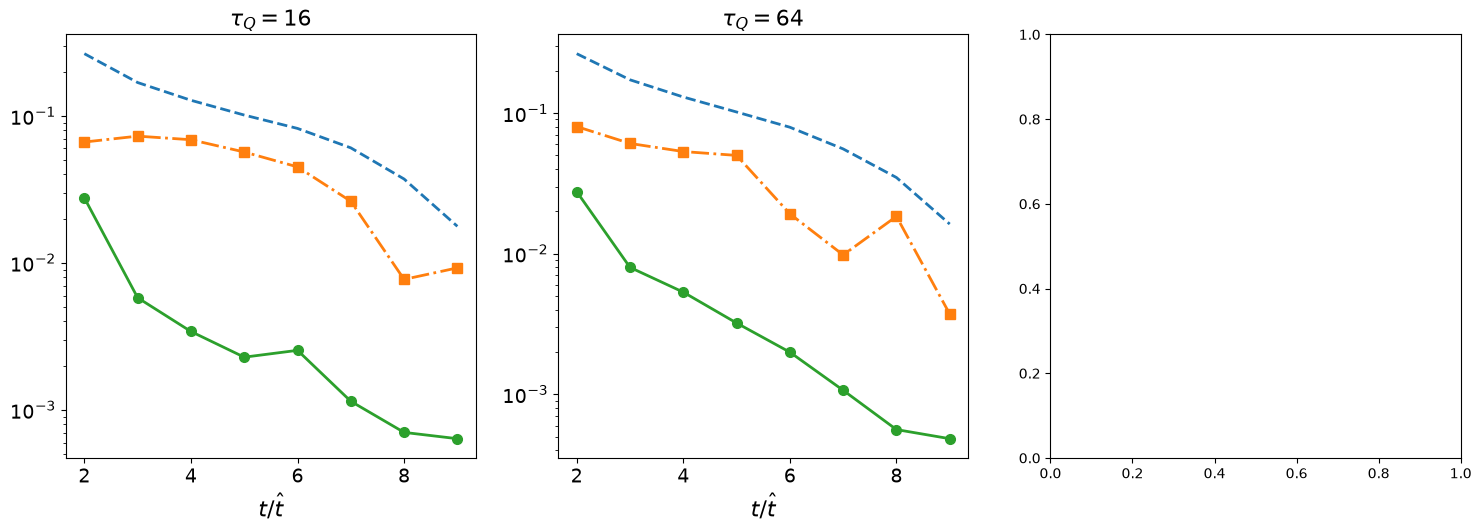

In [39]:
from scipy.ndimage import gaussian_filter

# ---- inputs ----
TAUS     = [16, 64, 256]
T_LIST   = [2, 3, 4, 5, 6, 7, 8, 9]          # units of t_hat
SIGMAS   = [0, 1, 2, 4, 8, 16, 32]           # Gaussian smoothing width, lattice sites
TARGET   = "y_end"
FONTSIZE = 16

fig, axes = plt.subplots(1, len(TAUS), figsize=(6 * len(TAUS), 5.5), squeeze=False)

for ax, tau in zip(axes[0], TAUS):
    d = an.load_chunk(tau, chunk=0)
    Y = d[TARGET]
    xi_hat_sites = float(d["xi_hat"]) / float(d["dx"])

    err_pers, err_smooth = [], []
    for t in T_LIST:
        X, _ = an.snapshot_at(d, t)
        errs = []
        for s in SIGMAS:
            Xs = gaussian_filter(X, sigma=(0, s, s), mode="wrap") if s > 0 else X   # periodic smoothing
            errs.append(((Xs > 0) != Y).mean())
        err_pers.append(errs[0])
        err_smooth.append(min(errs))
        print(f"tau={tau:4d}  t={t}  persistence={errs[0]:.3f}  best smoothed={min(errs):.3f}  "
              f"at sigma={SIGMAS[int(np.argmin(errs))]} sites ({SIGMAS[int(np.argmin(errs))] / xi_hat_sites:.1f} xi_hat)")

    t_u, _, em = an.as_arrays(an.load_results(tau, target=TARGET))
    ax.semilogy(T_LIST, err_pers,   "--",  lw=2, label="persistence")
    ax.semilogy(T_LIST, err_smooth, "s-.", lw=2, ms=7, label="smoothed persistence (best σ)")
    ax.semilogy(t_u,    em,         "o-",  lw=2, ms=7, label="U-Net")
    ax.set_title(rf"$\tau_Q = {tau}$", fontsize=FONTSIZE)
    ax.set_xlabel(r"$t/\hat t$", fontsize=FONTSIZE)
    ax.tick_params(labelsize=FONTSIZE - 2)

axes[0, 0].set_ylabel("error rate", fontsize=FONTSIZE)
axes[0, 0].legend(fontsize=FONTSIZE - 4)
plt.tight_layout()
plt.savefig("../figures/2d/smoothed_baseline.png", dpi=150)
plt.show()

In [ ]:
from scipy.ndimage import gaussian_filter

# ---- inputs ----
TAU      = 32
T_LIST   = [2, 4,6,8]                       # input times, units of t_hat
SIGMAS   = [1, 2, 4, 8, 16, 32]            # candidate blur widths, lattice sites
TARGET   = "y_end"
PICK     = 0                               # which test sample in chunk 0
SEED     = 0
FONTSIZE = 16

# ---- test-split sample in chunk 0 (same split as training) ----
n_total  = an.load_results(TAU, target=TARGET)[0]["n_samples"]
test_idx = np.random.default_rng(SEED).permutation(n_total)[: n_total // 10]
d        = an.load_chunk(TAU, chunk=0)
s        = int(np.sort(test_idx[test_idx < len(d[TARGET])])[PICK])
Y        = d[TARGET][s]

fig, axes = plt.subplots(len(T_LIST), 4, figsize=(16, 4.2 * len(T_LIST)), squeeze=False)

for row, t in enumerate(T_LIST):
    X, t_used = an.snapshot_at(d, t)

    # best blur for this time, chosen on the whole chunk
    errs  = [((gaussian_filter(X, sigma=(0, sg, sg), mode="wrap") > 0) != d[TARGET]).mean() for sg in SIGMAS]
    sigma = SIGMAS[int(np.argmin(errs))]
    xb    = gaussian_filter(X[s], sigma=sigma, mode="wrap")

    model, meta = an.load_model(os.path.join(an.RESULTS, f"tau{TAU}_that{t:g}_{TARGET}"))
    pred = an.predict(model, X[[s]], meta["scale"])[0]

    x = X[s]
    v, vb = np.abs(x).max(), np.abs(xb).max()
    axes[row, 0].imshow(x,  cmap="RdBu_r", vmin=-v,  vmax=v,  interpolation="nearest")
    axes[row, 1].imshow(xb, cmap="RdBu_r", vmin=-vb, vmax=vb, interpolation="nearest")
    axes[row, 1].contour(xb, levels=[0], colors="k", linewidths=1.5)
    axes[row, 2].imshow(pred, cmap="RdBu_r", vmin=0, vmax=1, interpolation="nearest")
    axes[row, 3].imshow(Y,    cmap="RdBu_r", vmin=0, vmax=1, interpolation="nearest")

    axes[row, 0].set_ylabel(rf"$t = {t_used:g}\,\hat t$", fontsize=FONTSIZE)
    axes[row, 1].set_title(rf"σ = {sigma} sites,  err {((xb > 0) != Y).mean():.3f}", fontsize=FONTSIZE - 2)
    axes[row, 2].set_title(f"err {(pred != Y).mean():.3f}", fontsize=FONTSIZE - 2)

for col, lab in enumerate(["input", "blurred input", "U-Net prediction", "truth (end)"]):
    axes[0, col].annotate(lab, xy=(0.5, 1.18), xycoords="axes fraction",
                          ha="center", fontsize=FONTSIZE)
for ax in axes.ravel():
    ax.set_xticks([]); ax.set_yticks([])

fig.suptitle(rf"$\tau_Q = {TAU}$, test sample {s}", fontsize=FONTSIZE + 2, y=1.02)
plt.tight_layout()
plt.savefig(f"../figures/2d/blur_vs_unet_tau{TAU}.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# ---- inputs ----
TAUS     = [8, 16, 32, 64, 128, 256]
T_LIST   = [2, 3, 4, 5, 6, 7, 8, 9]            # units of t_hat
KC_MULT  = np.geomspace(0.05, 3.0, 25)         # cutoffs k_c, in units of 1/xi_hat
TARGET   = "y_end"
FONTSIZE = 16

best_kc, best_err = {}, {}
for tau in TAUS:
    d = an.load_chunk(tau, chunk=0)
    Y = d[TARGET]
    N, dx, xi_hat = int(d["N"]), float(d["dx"]), float(d["xi_hat"])
    k_min = 2 * np.pi / (N * dx)                              # smallest nonzero mode in the box

    # |k| on the rfft2 grid
    kx = 2 * np.pi * np.fft.fftfreq(N, d=dx)
    ky = 2 * np.pi * np.fft.rfftfreq(N, d=dx)
    K  = np.sqrt(kx[:, None]**2 + ky[None, :]**2)

    best_kc[tau], best_err[tau] = [], []
    for t in T_LIST:
        X, _ = an.snapshot_at(d, t)
        F = np.fft.rfft2(X, axes=(-2, -1))

        errs = []
        for m in KC_MULT:
            kc = m / xi_hat
            if kc < k_min:                                    # cutoff below the box's lowest mode
                errs.append(np.nan); continue
            Xf = np.fft.irfft2(F * (K <= kc), s=(N, N), axes=(-2, -1))
            errs.append(((Xf > 0) != Y).mean())

        j = int(np.nanargmin(errs))
        best_kc[tau].append(KC_MULT[j])
        best_err[tau].append(errs[j])
        print(f"tau={tau:4d}  t={t}  best k_c*xi_hat = {KC_MULT[j]:.2f}   "
              f"lambda_c = {2 * np.pi / KC_MULT[j]:5.1f} xi_hat   err = {errs[j]:.3f}")

# ---- plot: best cutoff and its error vs time, all tau ----
colors = plt.cm.viridis(np.linspace(0, 0.9, len(TAUS)))
fig, ax = plt.subplots(1, 2, figsize=(15, 6))
for tau, c in zip(TAUS, colors):
    ax[0].plot(T_LIST, best_kc[tau],  "o-", color=c, ms=7, lw=2, label=rf"$\tau_Q = {tau}$")
    ax[1].semilogy(T_LIST, best_err[tau], "o-", color=c, ms=7, lw=2, label=rf"$\tau_Q = {tau}$")

ax[0].set_ylabel(r"best cutoff $k_c \hat\xi$", fontsize=FONTSIZE)
ax[1].set_ylabel("error of best low-pass", fontsize=FONTSIZE)
for a in ax:
    a.set_xlabel(r"$t/\hat t$", fontsize=FONTSIZE)
    a.tick_params(labelsize=FONTSIZE - 2)
    a.legend(fontsize=FONTSIZE - 4)
plt.tight_layout()
plt.savefig("../figures/2d/lowpass_best_kc.png", dpi=150)
plt.show()

In [ ]:
# ---- inputs ----
TAUS     = [8, 16, 32, 64, 128, 256]
T_LIST   = [2, 4, 6, 8]                        # fixed input times, units of t_hat
KC_MULT  = np.geomspace(0.1, 1.5, 40)          # cutoffs k_c, units of 1/xi_hat (finer grid)
TARGET   = "y_end"
FONTSIZE = 16

best = {t: [] for t in T_LIST}                 # best k_c*xi_hat per (t, tau)
floor = []                                     # box's lowest mode per tau, units of 1/xi_hat

for tau in TAUS:
    d = an.load_chunk(tau, chunk=0)
    Y = d[TARGET]
    N, dx, xi_hat = int(d["N"]), float(d["dx"]), float(d["xi_hat"])
    k_min = 2 * np.pi / (N * dx)
    floor.append(k_min * xi_hat)

    kx = 2 * np.pi * np.fft.fftfreq(N, d=dx)
    ky = 2 * np.pi * np.fft.rfftfreq(N, d=dx)
    K  = np.sqrt(kx[:, None]**2 + ky[None, :]**2)

    for t in T_LIST:
        X, _ = an.snapshot_at(d, t)
        F = np.fft.rfft2(X, axes=(-2, -1))
        errs = []
        for m in KC_MULT:
            if m / xi_hat < k_min:
                errs.append(np.nan); continue
            Xf = np.fft.irfft2(F * (K <= m / xi_hat), s=(N, N), axes=(-2, -1))
            errs.append(((Xf > 0) != Y).mean())
        best[t].append(KC_MULT[int(np.nanargmin(errs))])

    print(f"tau={tau:4d}  " + "  ".join(f"t={t}: {best[t][-1]:.2f}" for t in T_LIST)
          + f"   (box floor {floor[-1]:.2f})")

# ---- plot: best cutoff vs tau, one line per input time ----
colors = plt.cm.plasma(np.linspace(0, 0.85, len(T_LIST)))
plt.figure(figsize=(9, 6))
for t, c in zip(T_LIST, colors):
    plt.plot(TAUS, best[t], "o-", color=c, ms=9, lw=2, label=rf"$t = {t}\,\hat t$")
plt.plot(TAUS, floor, "k:", lw=2, label="box floor $2\\pi\\hat\\xi/L$")
plt.xscale("log")
plt.xlabel(r"$\tau_Q$", fontsize=FONTSIZE)
plt.ylabel(r"best cutoff $k_c\hat\xi$", fontsize=FONTSIZE)
plt.tick_params(labelsize=FONTSIZE - 2)
plt.legend(fontsize=FONTSIZE - 3)
plt.tight_layout()
plt.savefig("../figures/2d/best_kc_vs_tau.png", dpi=150)
plt.show()

# Part 3 


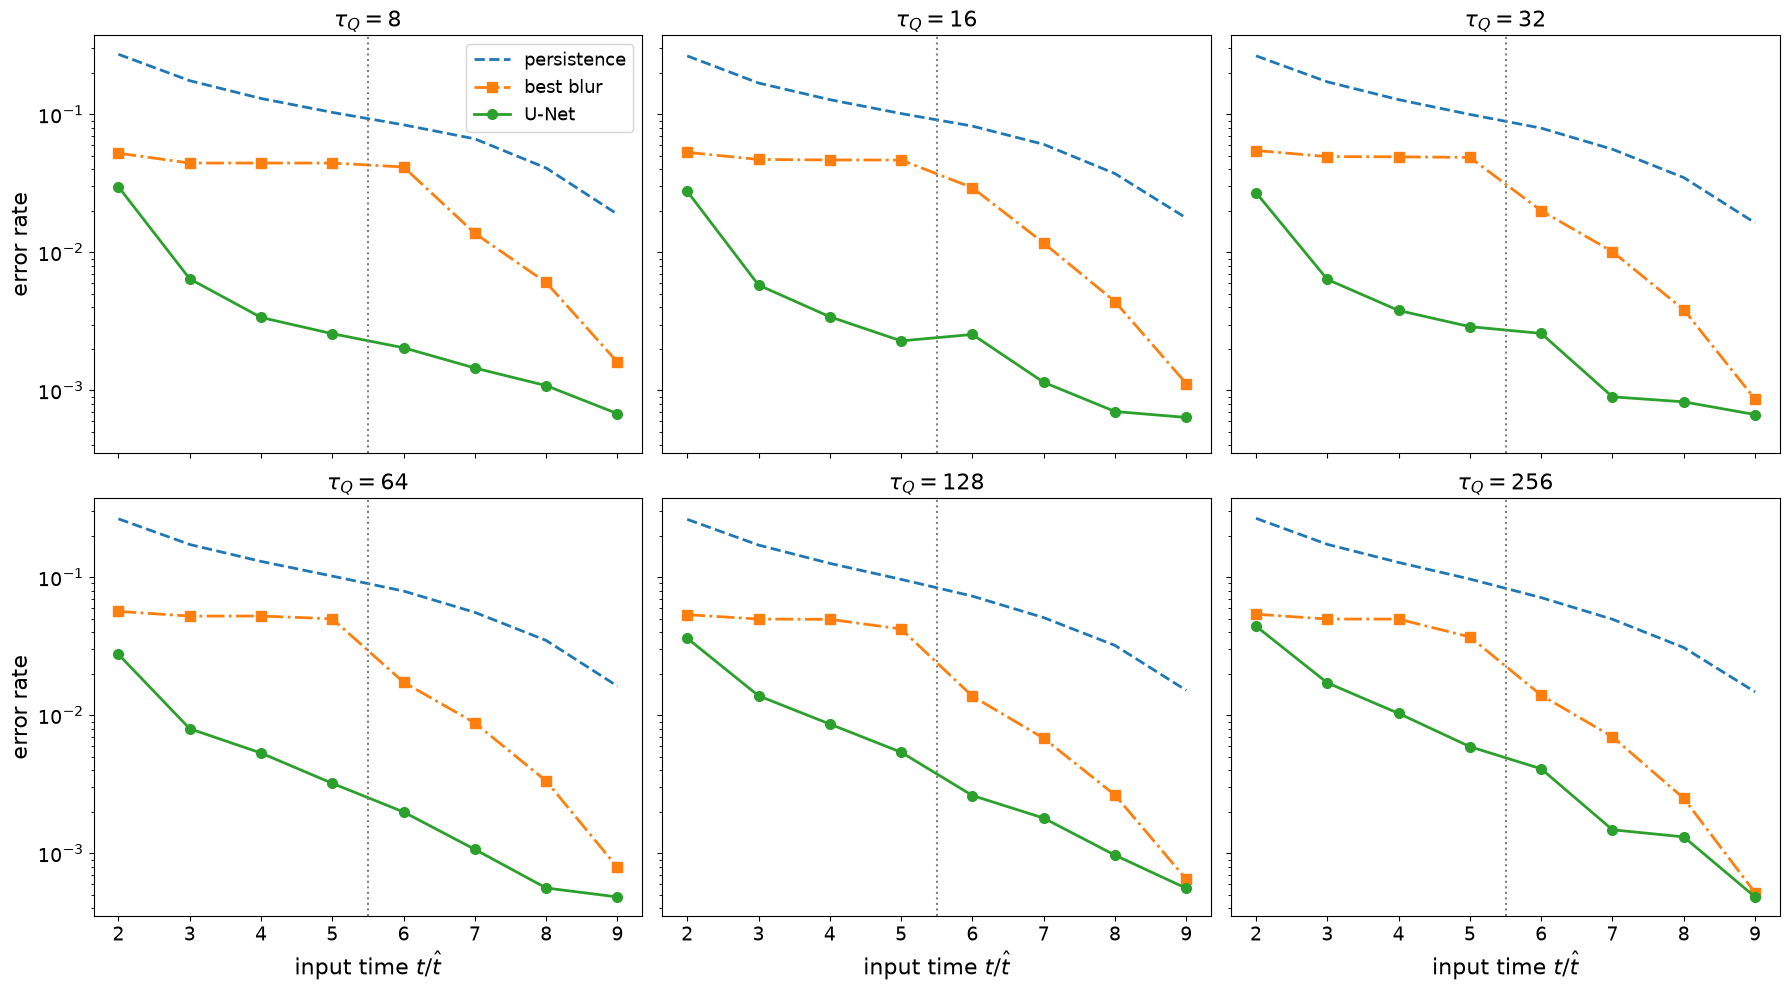

In [40]:
# ---- inputs ----
TAUS     = [8, 16, 32, 64, 128, 256]
TARGET   = "y_end"
T_FORM   = 5.5                          # approximate formation time, units of t_hat
FONTSIZE = 16

fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True, sharey=True)

for ax, tau in zip(axes.ravel(), TAUS):
    t_u, _, em = an.as_arrays(an.load_results(tau, target=TARGET))

    ax.semilogy(blur_t, pers_err[tau], "--",  color="C0", lw=2, label="persistence")
    ax.semilogy(blur_t, blur_err[tau], "s-.", color="C1", lw=2, ms=7, label="best blur")
    ax.semilogy(t_u,    em,            "o-",  color="C2", lw=2, ms=7, label="U-Net")
    ax.axvline(T_FORM, color="grey", ls=":", lw=1.5)

    ax.set_title(rf"$\tau_Q = {tau}$", fontsize=FONTSIZE)
    ax.tick_params(labelsize=FONTSIZE - 2)

for ax in axes[1]:
    ax.set_xlabel(r"input time $t/\hat t$", fontsize=FONTSIZE)
for ax in axes[:, 0]:
    ax.set_ylabel("error rate", fontsize=FONTSIZE)
axes[0, 0].legend(fontsize=FONTSIZE - 3)

plt.tight_layout()
plt.savefig("../figures/2d/unet_vs_blur_vs_persistence.png", dpi=150)
plt.show()

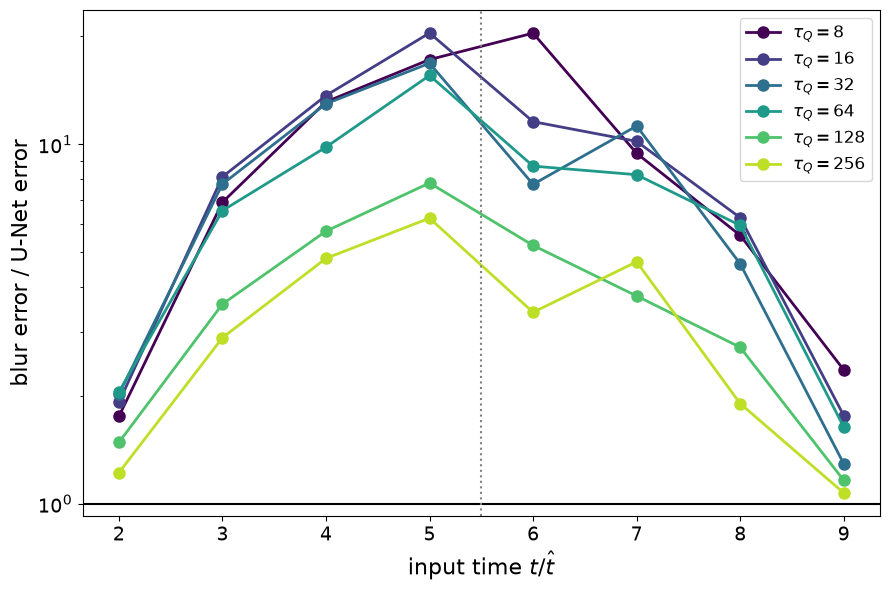

In [41]:
# ---- inputs ----
TAUS     = [8, 16, 32, 64, 128, 256]
TARGET   = "y_end"
T_FORM   = 5.5
FONTSIZE = 16

colors = plt.cm.viridis(np.linspace(0, 0.9, len(TAUS)))
plt.figure(figsize=(9, 6))
for tau, c in zip(TAUS, colors):
    t_u, _, em = an.as_arrays(an.load_results(tau, target=TARGET))
    be = np.array([blur_err[tau][blur_t.index(t)] for t in t_u])     # blur error at the same times
    plt.semilogy(t_u, be / em, "o-", color=c, ms=8, lw=2, label=rf"$\tau_Q = {tau}$")

plt.axhline(1, color="k", lw=1.5)                                    # 1 = U-Net no better than blur
plt.axvline(T_FORM, color="grey", ls=":", lw=1.5)
plt.xlabel(r"input time $t/\hat t$", fontsize=FONTSIZE)
plt.ylabel("blur error / U-Net error", fontsize=FONTSIZE)
plt.tick_params(labelsize=FONTSIZE - 2)
plt.legend(fontsize=FONTSIZE - 4)
plt.tight_layout()
plt.savefig("../figures/2d/unet_advantage.png", dpi=150)
plt.show()

In [42]:
# ---- inputs ----
TAUS   = [8, 16, 32, 64, 128, 256]
TARGET = "y_end"

for tau in TAUS:
    d = an.load_chunk(tau, chunk=0)
    N, dx = int(d["N"]), float(d["dx"])
    L = N * dx
    ell = L**2 / an.wall_length(d[TARGET], dx=dx)          # one value per sample
    print(f"tau={tau:4d}  ell_end/L = {ell.mean():.3f} ± {ell.std():.3f}   "
          f"~domains per box = {(L / (2 * ell.mean()))**2:5.1f}")

tau=   8  ell_end/L = 14.827 ± 1.191   ~domains per box =  18.6
tau=  16  ell_end/L = 18.509 ± 1.825   ~domains per box =  12.0
tau=  32  ell_end/L = 22.789 ± 2.483   ~domains per box =   7.9
tau=  64  ell_end/L = 27.515 ± 3.006   ~domains per box =   5.4
tau= 128  ell_end/L = 38.707 ± 25.991   ~domains per box =   2.7
tau= 256  ell_end/L = 44.898 ± 15.905   ~domains per box =   2.0


In [43]:
from matplotlib.colors import ListedColormap

tau=16: 3 test samples
  t=2:  both right 93.16%   U-Net fixes blur 3.85%   both wrong 1.86%   U-Net worse 1.13%
  t=6:  both right 96.59%   U-Net fixes blur 3.17%   both wrong 0.11%   U-Net worse 0.13%


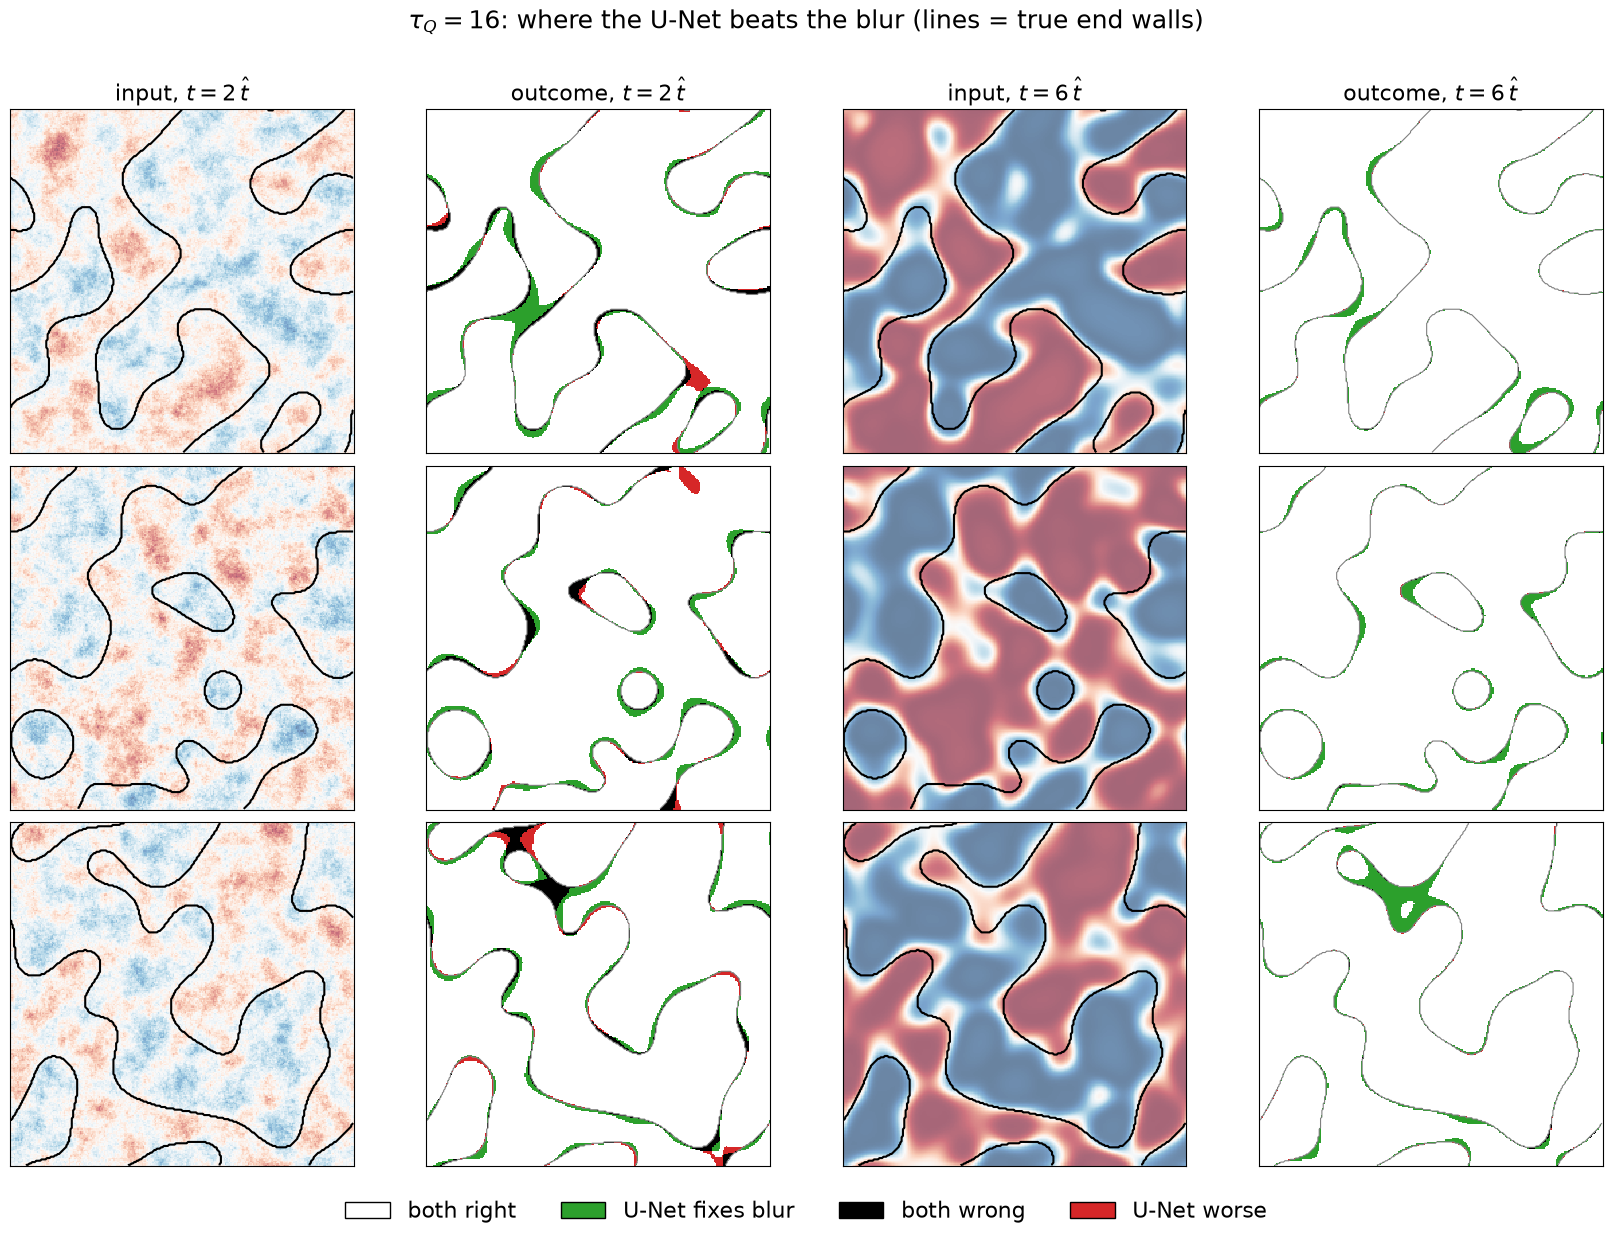

In [48]:
# ---- inputs ----
TAU      = 16
T_SHOW   = [2,6]                  # one time before formation, one after (units of t_hat)
CHUNKS   = [0]                     # chunks to draw test samples from (add more if available)
N_SHOW   = 3                       # samples (rows) to plot
TARGET   = "y_end"
SEED     = 0                       # split seed used in training
FONTSIZE = 16

# categories: 0 both right, 1 blur wrong / U-Net right, 2 both wrong, 3 U-Net wrong / blur right
CAT_CMAP  = ListedColormap(["white", "#2ca02c", "black", "#d62728"])
CAT_NAMES = ["both right", "U-Net fixes blur", "both wrong", "U-Net worse"]

# ---- test-split indices (same split as kz_ml.make_loaders) ----
n_total  = an.load_results(TAU, target=TARGET)[0]["n_samples"]
test_idx = np.random.default_rng(SEED).permutation(n_total)[: n_total // 10]

# ---- predictions for every test sample in CHUNKS, at each time ----
cats, inputs, truth = {t: [] for t in T_SHOW}, {t: [] for t in T_SHOW}, []
for c in CHUNKS:
    d = an.load_chunk(TAU, chunk=c)
    n_chunk = len(d[TARGET])
    local = np.sort(test_idx[(test_idx >= c * n_chunk) & (test_idx < (c + 1) * n_chunk)]) - c * n_chunk
    if len(local) == 0:
        continue
    Y = d[TARGET][local]
    truth.extend(Y)

    N, dx, xi_hat = int(d["N"]), float(d["dx"]), float(d["xi_hat"])
    kx = 2 * np.pi * np.fft.fftfreq(N, d=dx)
    ky = 2 * np.pi * np.fft.rfftfreq(N, d=dx)
    K2 = kx[:, None]**2 + ky[None, :]**2

    for t in T_SHOW:
        X, _ = an.snapshot_at(d, t)
        X = X[local]

        # best blur for this tau and time (from the scan)
        sigma = blur_sig[TAU][blur_t.index(t)] * xi_hat
        Xb = np.fft.irfft2(np.fft.rfft2(X, axes=(-2, -1)) * np.exp(-K2 * sigma**2 / 2),
                           s=(N, N), axes=(-2, -1))
        blur_wrong = (Xb > 0) != Y

        model, meta = an.load_model(os.path.join(an.RESULTS, f"tau{TAU}_that{t:g}_{TARGET}"))
        unet_wrong  = an.predict(model, X, meta["scale"]) != Y

        cat = np.zeros(Y.shape, dtype=int)
        cat[blur_wrong & ~unet_wrong] = 1
        cat[blur_wrong &  unet_wrong] = 2
        cat[~blur_wrong & unet_wrong] = 3
        cats[t].extend(cat)
        inputs[t].extend(X)

print(f"tau={TAU}: {len(truth)} test samples")
for t in T_SHOW:
    frac = np.bincount(np.array(cats[t]).ravel(), minlength=4) / np.array(cats[t]).size
    print(f"  t={t}:  " + "   ".join(f"{name} {100 * f:.2f}%" for name, f in zip(CAT_NAMES, frac)))

# ---- plot: for each time, input (with true end walls) and category map ----
n_rows = min(N_SHOW, len(truth))
fig, axes = plt.subplots(n_rows, 2 * len(T_SHOW), figsize=(4.2 * 2 * len(T_SHOW), 4.2 * n_rows), squeeze=False)

for row in range(n_rows):
    for k, t in enumerate(T_SHOW):
        x = inputs[t][row]
        v = np.abs(x).max()
        ax = axes[row, 2 * k]
        ax.imshow(x, cmap="RdBu_r", vmin=-v, vmax=v, alpha=0.6, interpolation="nearest")
        ax.contour(truth[row].astype(float), levels=[0.5], colors="k", linewidths=1.5)   # true end walls
        ax = axes[row, 2 * k + 1]
        ax.imshow(cats[t][row], cmap=CAT_CMAP, vmin=-0.5, vmax=3.5, interpolation="nearest")
        ax.contour(truth[row].astype(float), levels=[0.5], colors="grey", linewidths=0.8)
        if row == 0:
            axes[0, 2 * k].set_title(rf"input, $t = {t}\,\hat t$", fontsize=FONTSIZE)
            axes[0, 2 * k + 1].set_title(rf"outcome, $t = {t}\,\hat t$", fontsize=FONTSIZE)

for ax in axes.ravel():
    ax.set_xticks([]); ax.set_yticks([])

handles = [plt.Rectangle((0, 0), 1, 1, fc=CAT_CMAP(i), ec="k") for i in range(4)]
fig.legend(handles, CAT_NAMES, loc="lower center", ncol=4, fontsize=FONTSIZE, frameon=False)
fig.suptitle(rf"$\tau_Q = {TAU}$: where the U-Net beats the blur (lines = true end walls)",
             fontsize=FONTSIZE + 2)
plt.tight_layout(rect=(0, 0.05, 1, 0.97))
plt.savefig(f"../figures/2d/disagreement_tau{TAU}.png", dpi=150)
plt.show()

In [49]:
from scipy.ndimage import distance_transform_edt

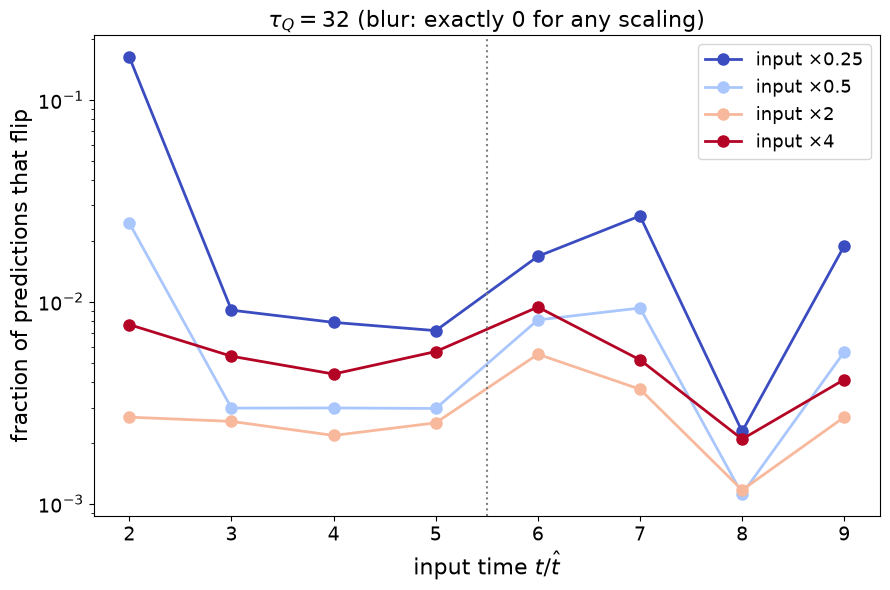

In [51]:
# ---- inputs ----
TAU      = 32
T_LIST   = [2, 3, 4, 5, 6, 7, 8, 9]
SCALES   = [0.25, 0.5, 2, 4]          # input multiplied by these factors
TARGET   = "y_end"
FONTSIZE = 16

d = an.load_chunk(TAU, chunk=0)
Y = d[TARGET]

changed = {a: [] for a in SCALES}     # fraction of sites whose prediction flips when input is scaled
for t in T_LIST:
    X, _ = an.snapshot_at(d, t)
    model, meta = an.load_model(os.path.join(an.RESULTS, f"tau{TAU}_that{t:g}_{TARGET}"))
    p1 = an.predict(model, X, meta["scale"])
    for a in SCALES:
        pa = an.predict(model, a * X, meta["scale"])
        changed[a].append((pa != p1).mean())

colors = plt.cm.coolwarm(np.linspace(0, 1, len(SCALES)))
plt.figure(figsize=(9, 6))
for a, c in zip(SCALES, colors):
    plt.semilogy(T_LIST, changed[a], "o-", color=c, ms=8, lw=2, label=rf"input $\times {a:g}$")
plt.axvline(5.5, color="grey", ls=":", lw=1.5)
plt.xlabel(r"input time $t/\hat t$", fontsize=FONTSIZE)
plt.ylabel("fraction of predictions that flip", fontsize=FONTSIZE)
plt.title(rf"$\tau_Q = {TAU}$ (blur: exactly 0 for any scaling)", fontsize=FONTSIZE)
plt.tick_params(labelsize=FONTSIZE - 2)
plt.legend(fontsize=FONTSIZE - 3)
plt.tight_layout()
plt.savefig(f"../figures/2d/amplitude_test_tau{TAU}.png", dpi=150)
plt.show()

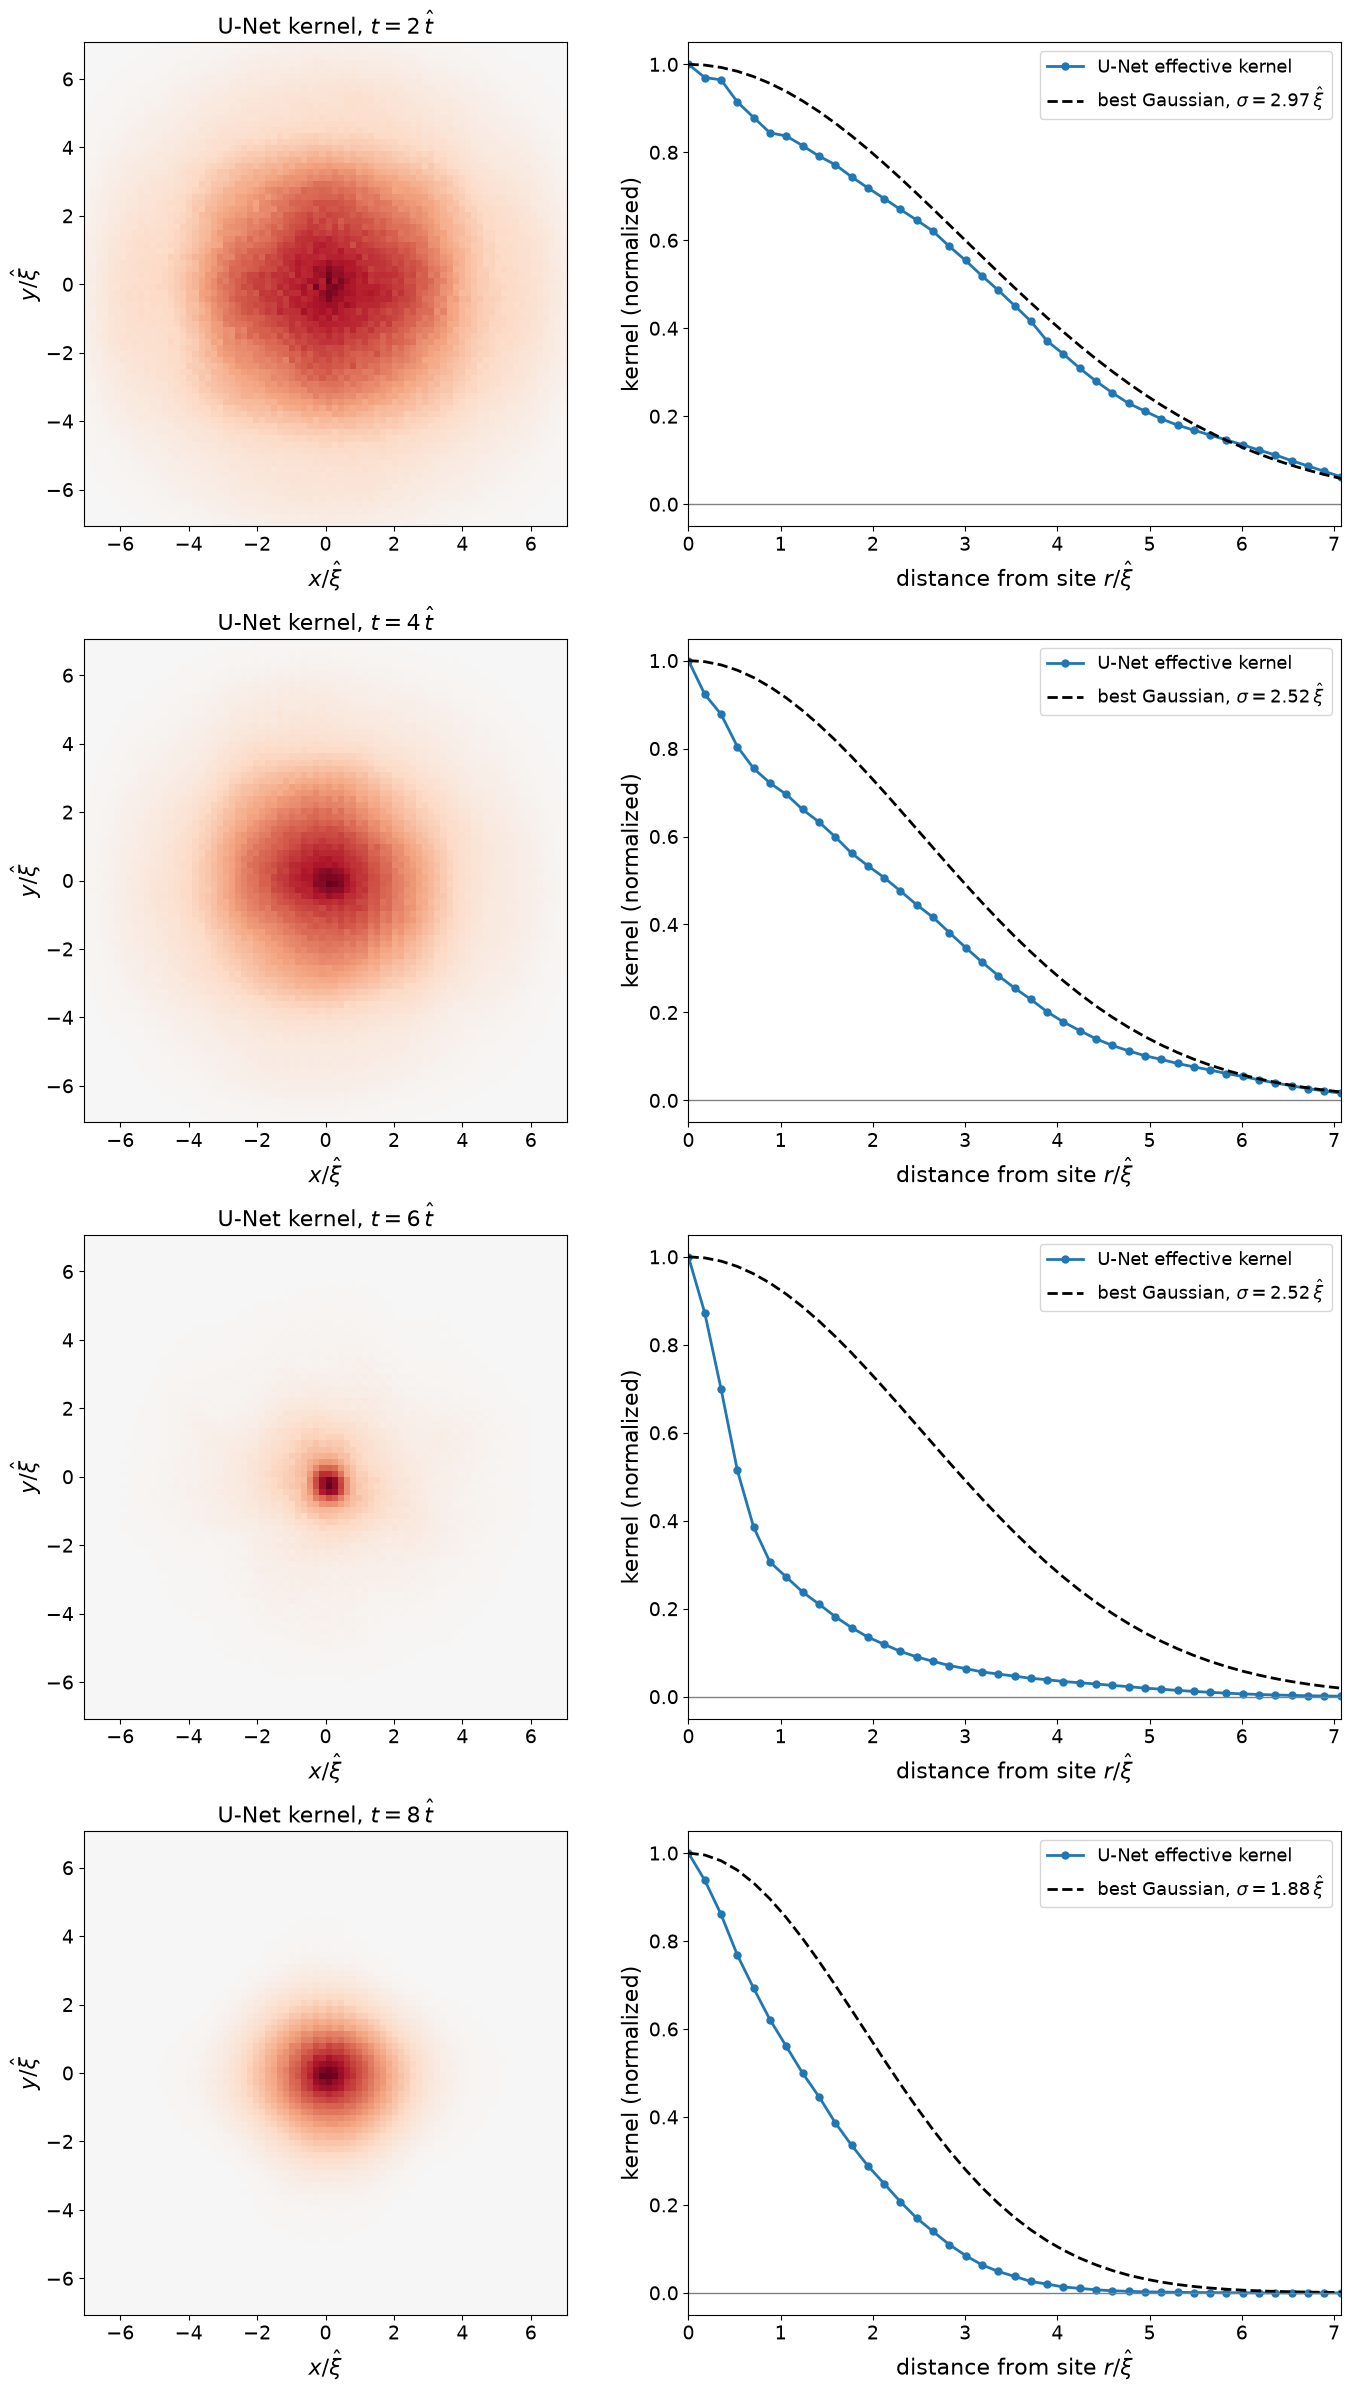

In [57]:
# ---- inputs ----
TAU      = 32
T_SHOW   = [2,4,6,8]                 # before and after formation, units of t_hat
N_SAMP   = 10                     # samples to average over
N_SITES  = 20                     # sites per sample (one backward pass each, batched over samples)
NEAR     = 2                      # sites within this many lattice spacings of a true end wall
WIN      = 40                     # half-width of the kernel window shown, lattice sites
TARGET   = "y_end"
SEED     = 0
FONTSIZE = 16

d = an.load_chunk(TAU, chunk=0)
N, dx, xi_hat = int(d["N"]), float(d["dx"]), float(d["xi_hat"])
Y = d[TARGET][:N_SAMP]
rng = np.random.default_rng(SEED)

# radial distance from the window centre, units of xi_hat
yy, xx = np.mgrid[-N // 2:N // 2, -N // 2:N // 2]
R = np.sqrt(xx**2 + yy**2) * dx / xi_hat
rbin = np.round(np.sqrt(xx**2 + yy**2)).astype(int)

fig, axes = plt.subplots(len(T_SHOW), 2, figsize=(14, 6 * len(T_SHOW)), squeeze=False)

for row, t in enumerate(T_SHOW):
    X, _ = an.snapshot_at(d, t)
    X = X[:N_SAMP]
    model, meta = an.load_model(os.path.join(an.RESULTS, f"tau{TAU}_that{t:g}_{TARGET}"))

    # candidate sites: close to a true end wall
    near = []
    for Yi in Y:
        wall = (Yi != np.roll(Yi, 1, 0)) | (Yi != np.roll(Yi, 1, 1))
        for _ in range(NEAR):
            wall = wall | np.roll(wall, 1, 0) | np.roll(wall, -1, 0) | np.roll(wall, 1, 1) | np.roll(wall, -1, 1)
        near.append(np.argwhere(wall))

    kernel = np.zeros((N, N))
    xin = torch.from_numpy(X[:, None] / meta["scale"]).float()
    for _ in range(N_SITES):
        sites = np.array([s[rng.integers(len(s))] for s in near])          # one site per sample
        x = xin.clone().requires_grad_(True)
        out = model(x)
        out[np.arange(N_SAMP), 0, sites[:, 0], sites[:, 1]].sum().backward()
        g = x.grad.numpy()[:, 0]
        for b in range(N_SAMP):                                             # centre each kernel on its site
            kernel += np.roll(g[b], (N // 2 - sites[b, 0], N // 2 - sites[b, 1]), axis=(0, 1))
    kernel /= N_SAMP * N_SITES
    kernel_c = np.fft.fftshift(np.fft.ifftshift(kernel))                    # site at the centre of the array

    # radial profile of the U-Net kernel vs the best Gaussian blur, both normalized to 1 at r = 0
    prof  = np.bincount(rbin.ravel(), weights=kernel_c.ravel()) / np.bincount(rbin.ravel())
    r_pr  = np.arange(len(prof)) * dx / xi_hat
    sigma = blur_sig[TAU][blur_t.index(t)]                                  # units of xi_hat
    ax = axes[row, 1]
    ax.plot(r_pr, prof / prof[0], "o-", ms=5, lw=2, label="U-Net effective kernel")
    ax.plot(r_pr, np.exp(-r_pr**2 / (2 * sigma**2)), "k--", lw=2, label=rf"best Gaussian, $\sigma = {sigma:.2f}\,\hat\xi$")
    ax.axhline(0, color="grey", lw=1)
    ax.set_xlim(0, WIN * dx / xi_hat)
    ax.set_xlabel(r"distance from site $r/\hat\xi$", fontsize=FONTSIZE)
    ax.set_ylabel("kernel (normalized)", fontsize=FONTSIZE)
    ax.legend(fontsize=FONTSIZE - 3)
    ax.tick_params(labelsize=FONTSIZE - 2)

    # the 2D kernel itself
    c = N // 2
    k2 = kernel_c[c - WIN:c + WIN, c - WIN:c + WIN]
    v = np.abs(k2).max()
    ext = WIN * dx / xi_hat
    axes[row, 0].imshow(k2, cmap="RdBu_r", vmin=-v, vmax=v, extent=[-ext, ext, -ext, ext])
    axes[row, 0].set_title(rf"U-Net kernel, $t = {t}\,\hat t$", fontsize=FONTSIZE)
    axes[row, 0].set_xlabel(r"$x/\hat\xi$", fontsize=FONTSIZE)
    axes[row, 0].set_ylabel(r"$y/\hat\xi$", fontsize=FONTSIZE)
    axes[row, 0].tick_params(labelsize=FONTSIZE - 2)

plt.tight_layout()
plt.savefig(f"../figures/2d/unet_kernel_tau{TAU}.png", dpi=150)
plt.show()

In [58]:
# fit a Gaussian A*exp(-r^2 / 2 s^2) to the radial profile, area-weighted; report the unexplained fraction
w      = r_pr + 1e-12                                   # area weight ~ r in 2D
s_grid = np.linspace(0.2, 6, 300)                       # candidate widths, units of xi_hat

best = (np.inf, None, None)
for s in s_grid:
    g = np.exp(-r_pr**2 / (2 * s**2))
    A = np.sum(w * prof * g) / np.sum(w * g * g)        # best amplitude for this width (least squares)
    resid = np.sum(w * (prof - A * g)**2)
    if resid < best[0]:
        best = (resid, s, A)

resid, s_fit, A_fit = best
non_gauss = resid / np.sum(w * prof**2)
print(f"t={t}: fitted sigma = {s_fit:.2f} xi_hat   non-Gaussianity = {non_gauss:.3f}")

t=8: fitted sigma = 1.40 xi_hat   non-Gaussianity = 0.004


t=2: fitted sigma = 2.88 xi_hat   best blur = 2.86 xi_hat   non-Gaussianity = 0.000
t=3: fitted sigma = 2.66 xi_hat   best blur = 2.65 xi_hat   non-Gaussianity = 0.001
t=4: fitted sigma = 2.41 xi_hat   best blur = 2.42 xi_hat   non-Gaussianity = 0.001
t=5: fitted sigma = 2.12 xi_hat   best blur = 2.22 xi_hat   non-Gaussianity = 0.003
t=6: fitted sigma = 1.93 xi_hat   best blur = 2.39 xi_hat   non-Gaussianity = 0.027
t=7: fitted sigma = 1.67 xi_hat   best blur = 2.25 xi_hat   non-Gaussianity = 0.002
t=8: fitted sigma = 1.62 xi_hat   best blur = 1.86 xi_hat   non-Gaussianity = 0.002
t=9: fitted sigma = 1.27 xi_hat   best blur = 1.37 xi_hat   non-Gaussianity = 0.022


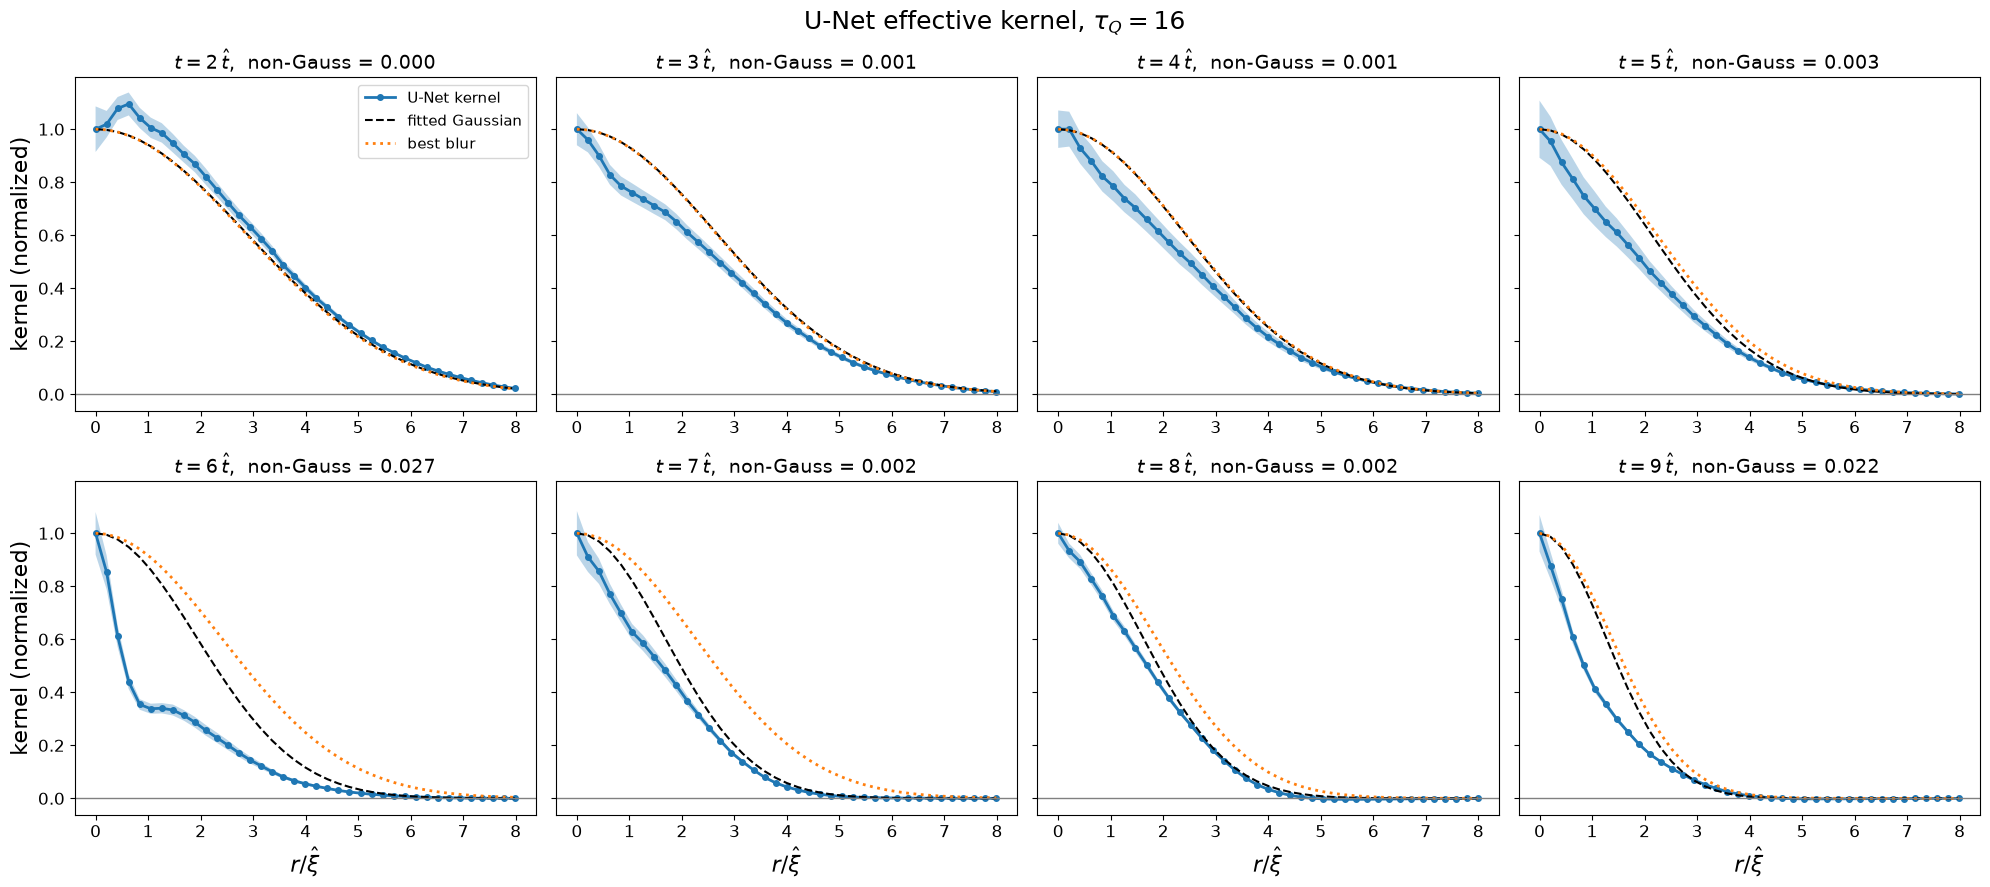

In [60]:
# ---- inputs ----
TAU      = 16
T_LIST_K = [2, 3, 4, 5, 6, 7, 8, 9]    # input times, units of t_hat
N_SAMP   = 10                          # samples to average over
N_SITES  = 20                          # sites per sample (one backward pass each, batched over samples)
NEAR     = 2                           # sites within this many lattice spacings of a true end wall
R_MAX    = 8.0                         # largest radius shown, units of xi_hat
TARGET   = "y_end"
SEED     = 0
FONTSIZE = 16

d = an.load_chunk(TAU, chunk=0)
N, dx, xi_hat = int(d["N"]), float(d["dx"]), float(d["xi_hat"])
Y = d[TARGET][:N_SAMP]
rng = np.random.default_rng(SEED)

# radial bins around the window centre (site is rolled to index N//2)
yy, xx = np.mgrid[-N // 2:N // 2, -N // 2:N // 2]
rbin   = np.round(np.sqrt(xx**2 + yy**2)).astype(int)
nbin   = np.bincount(rbin.ravel())
r_pr   = np.arange(len(nbin)) * dx / xi_hat                # radius, units of xi_hat
w      = r_pr + 1e-12                                       # area weight ~ r in 2D
s_grid = np.linspace(0.2, 6, 300)                           # Gaussian widths to try, units of xi_hat

# candidate sites: close to a true end wall (same for every time)
near = []
for Yi in Y:
    wall = (Yi != np.roll(Yi, 1, 0)) | (Yi != np.roll(Yi, 1, 1))
    for _ in range(NEAR):
        wall = wall | np.roll(wall, 1, 0) | np.roll(wall, -1, 0) | np.roll(wall, 1, 1) | np.roll(wall, -1, 1)
    near.append(np.argwhere(wall))

prof_t, err_t, s_fit_t, non_gauss_t = {}, {}, {}, {}
for t in T_LIST_K:
    X, _ = an.snapshot_at(d, t)
    X = X[:N_SAMP]
    model, meta = an.load_model(os.path.join(an.RESULTS, f"tau{TAU}_that{t:g}_{TARGET}"))
    xin = torch.from_numpy(X[:, None] / meta["scale"]).float()

    # effective kernel: gradient of one output logit w.r.t. the input, centred on that site
    profs = []
    for _ in range(N_SITES):
        sites = np.array([s[rng.integers(len(s))] for s in near])          # one site per sample
        x = xin.clone().requires_grad_(True)
        out = model(x)
        out[np.arange(N_SAMP), 0, sites[:, 0], sites[:, 1]].sum().backward()
        g = x.grad.numpy()[:, 0]
        for b in range(N_SAMP):
            gc = np.roll(g[b], (N // 2 - sites[b, 0], N // 2 - sites[b, 1]), axis=(0, 1))
            profs.append(np.bincount(rbin.ravel(), weights=gc.ravel()) / nbin)

    profs = np.array(profs)
    prof  = profs.mean(axis=0)
    err   = profs.std(axis=0) / np.sqrt(len(profs))                        # standard error per radius
    prof_t[t], err_t[t] = prof / prof[0], err / prof[0]                    # normalized to 1 at r = 0

    # best-fit Gaussian (area-weighted); non-Gaussianity = fraction it can't explain
    best = (np.inf, None)
    for s in s_grid:
        gss = np.exp(-r_pr**2 / (2 * s**2))
        A = np.sum(w * prof * gss) / np.sum(w * gss * gss)
        resid = np.sum(w * (prof - A * gss)**2)
        if resid < best[0]:
            best = (resid, s)
    s_fit_t[t]     = best[1]
    non_gauss_t[t] = best[0] / np.sum(w * prof**2)
    print(f"t={t}: fitted sigma = {s_fit_t[t]:.2f} xi_hat   best blur = "
          f"{blur_sig[TAU][blur_t.index(t)]:.2f} xi_hat   non-Gaussianity = {non_gauss_t[t]:.3f}")

# ---- plot: one panel per time ----
ncol = 4
nrow = int(np.ceil(len(T_LIST_K) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(5 * ncol, 4.5 * nrow), squeeze=False, sharey=True)
m = r_pr <= R_MAX
for ax, t in zip(axes.ravel(), T_LIST_K):
    ax.plot(r_pr[m], prof_t[t][m], "o-", ms=4, lw=2, label="U-Net kernel")
    ax.fill_between(r_pr[m], prof_t[t][m] - 2 * err_t[t][m], prof_t[t][m] + 2 * err_t[t][m], alpha=0.3)
    ax.plot(r_pr[m], np.exp(-r_pr[m]**2 / (2 * s_fit_t[t]**2)), "k--", lw=1.5, label="fitted Gaussian")
    sb = blur_sig[TAU][blur_t.index(t)]
    ax.plot(r_pr[m], np.exp(-r_pr[m]**2 / (2 * sb**2)), ":", color="C1", lw=2, label="best blur")
    ax.axhline(0, color="grey", lw=1)
    ax.set_title(rf"$t = {t}\,\hat t$,  non-Gauss = {non_gauss_t[t]:.3f}", fontsize=FONTSIZE - 2)
    ax.tick_params(labelsize=FONTSIZE - 4)
for ax in axes[-1]:
    ax.set_xlabel(r"$r/\hat\xi$", fontsize=FONTSIZE)
for ax in axes[:, 0]:
    ax.set_ylabel("kernel (normalized)", fontsize=FONTSIZE)
for ax in axes.ravel()[len(T_LIST_K):]:
    ax.axis("off")
axes[0, 0].legend(fontsize=FONTSIZE - 5)
fig.suptitle(rf"U-Net effective kernel, $\tau_Q = {TAU}$", fontsize=FONTSIZE + 2)
plt.tight_layout()
plt.savefig(f"../figures/2d/unet_kernels_tau{TAU}.png", dpi=150)
plt.show()

t=2: 391 sites, rank correlation (curvature vs width) = -0.30
t=4: 400 sites, rank correlation (curvature vs width) = -0.23
t=5: 400 sites, rank correlation (curvature vs width) = -0.13
t=6: 400 sites, rank correlation (curvature vs width) = +0.18
t=8: 400 sites, rank correlation (curvature vs width) = +0.01


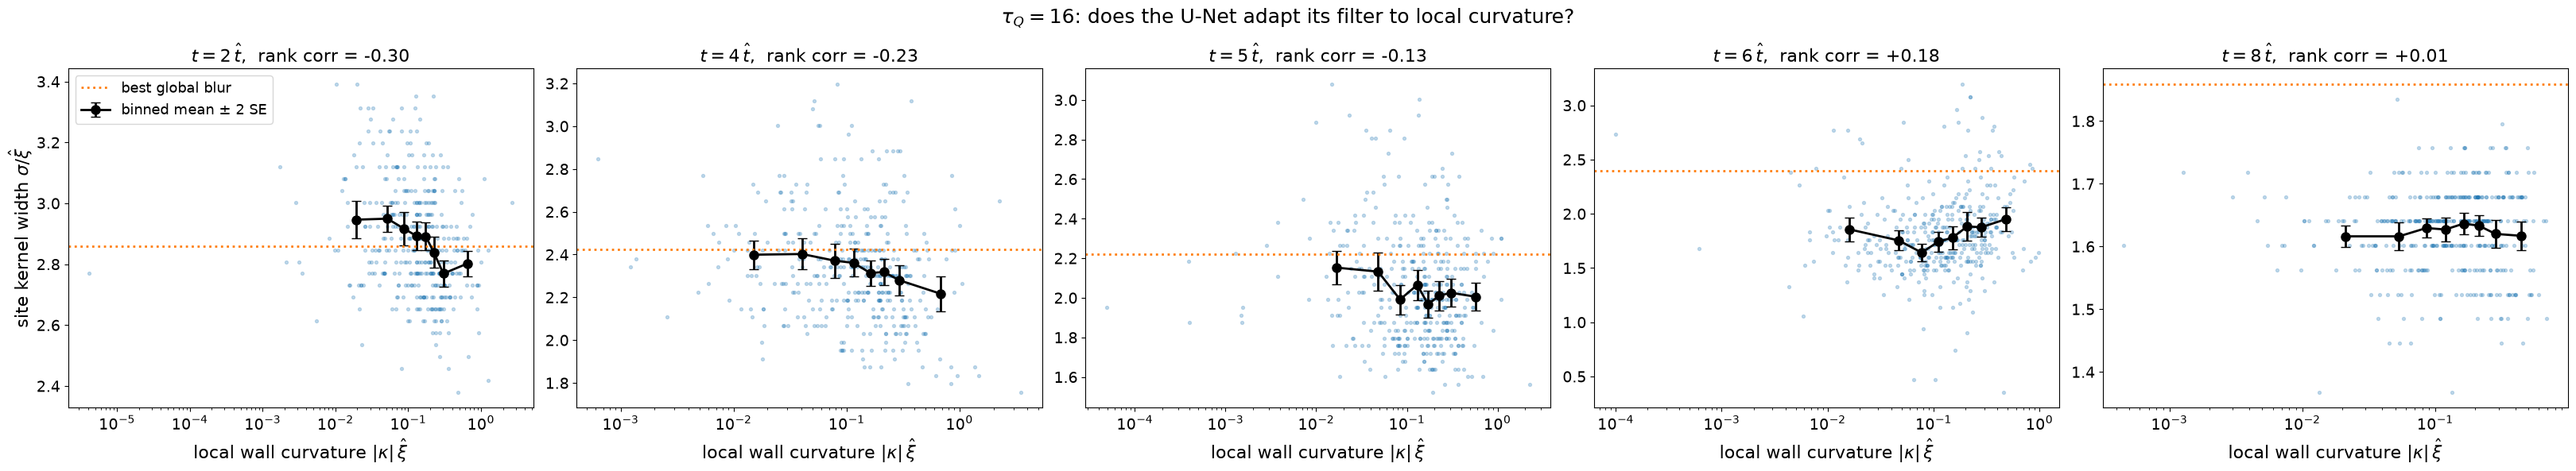

In [62]:
# ---- inputs ----
TAU      = 16
T_LIST_C = [2,4,5, 6, 8]                  # input times, units of t_hat (before, at, after formation)
N_SAMP   = 10
N_SITES  = 40                         # sites per sample
N_BINS   = 8                          # curvature bins for the averages
TARGET   = "y_end"
SEED     = 0
FONTSIZE = 16

d = an.load_chunk(TAU, chunk=0)
N, dx, xi_hat = int(d["N"]), float(d["dx"]), float(d["xi_hat"])
rng = np.random.default_rng(SEED)

# Fourier wavenumbers: axis 0 (y) full, axis 1 (x) half (rfft)
k0 = 2 * np.pi * np.fft.fftfreq(N, d=dx)[:, None]
k1 = 2 * np.pi * np.fft.rfftfreq(N, d=dx)[None, :]
K2 = k0**2 + k1**2

# radial bins for per-site profiles
yy, xx = np.mgrid[-N // 2:N // 2, -N // 2:N // 2]
rbin   = np.round(np.sqrt(xx**2 + yy**2)).astype(int)
nbin   = np.bincount(rbin.ravel())
r_pr   = np.arange(len(nbin)) * dx / xi_hat
w      = r_pr + 1e-12
s_grid = np.linspace(0.2, 6, 150)

fig, axes = plt.subplots(1, len(T_LIST_C), figsize=(6.5 * len(T_LIST_C), 6), squeeze=False)

for ax, t in zip(axes[0], T_LIST_C):
    X, _ = an.snapshot_at(d, t)
    X = X[:N_SAMP]
    model, meta = an.load_model(os.path.join(an.RESULTS, f"tau{TAU}_that{t:g}_{TARGET}"))

    # blurred input and its curvature (spectral derivatives, periodic)
    sigma = blur_sig[TAU][blur_t.index(t)] * xi_hat
    F   = np.fft.rfft2(X, axes=(-2, -1)) * np.exp(-K2 * sigma**2 / 2)
    ift = lambda G: np.fft.irfft2(G, s=(N, N), axes=(-2, -1))
    u    = ift(F)
    uy,  ux  = ift(1j * k0 * F), ift(1j * k1 * F)
    uyy, uxx, uxy = ift(-k0**2 * F), ift(-k1**2 * F), ift(-k0 * k1 * F)
    kappa = (uxx * uy**2 - 2 * ux * uy * uxy + uyy * ux**2) / ((ux**2 + uy**2)**1.5 + 1e-30)

    # sites on the input's walls (zero contour of the blurred field)
    near = []
    for ub in u:
        s = ub > 0
        near.append(np.argwhere((s != np.roll(s, 1, 0)) | (s != np.roll(s, 1, 1))))

    xin = torch.from_numpy(X[:, None] / meta["scale"]).float()
    widths, curvs = [], []
    for _ in range(N_SITES):
        sites = np.array([s[rng.integers(len(s))] for s in near])
        x = xin.clone().requires_grad_(True)
        out = model(x)
        out[np.arange(N_SAMP), 0, sites[:, 0], sites[:, 1]].sum().backward()
        g = x.grad.numpy()[:, 0]
        for b in range(N_SAMP):
            gc   = np.roll(g[b], (N // 2 - sites[b, 0], N // 2 - sites[b, 1]), axis=(0, 1))
            prof = np.bincount(rbin.ravel(), weights=gc.ravel()) / nbin
            if prof[0] <= 0:
                continue
            # this site's Gaussian width (area-weighted least squares)
            best = (np.inf, None)
            for sg in s_grid:
                gss = np.exp(-r_pr**2 / (2 * sg**2))
                A = np.sum(w * prof * gss) / np.sum(w * gss * gss)
                res = np.sum(w * (prof - A * gss)**2)
                if res < best[0]:
                    best = (res, sg)
            widths.append(best[1])
            curvs.append(abs(kappa[b, sites[b, 0], sites[b, 1]]) * xi_hat)

    widths, curvs = np.array(widths), np.array(curvs)

    # binned means (equal-count bins) and rank correlation
    edges = np.quantile(curvs, np.linspace(0, 1, N_BINS + 1))
    idx   = np.clip(np.digitize(curvs, edges) - 1, 0, N_BINS - 1)
    bc    = np.array([curvs[idx == i].mean() for i in range(N_BINS)])
    bm    = np.array([widths[idx == i].mean() for i in range(N_BINS)])
    be    = np.array([widths[idx == i].std() / np.sqrt((idx == i).sum()) for i in range(N_BINS)])
    rho   = np.corrcoef(np.argsort(np.argsort(curvs)), np.argsort(np.argsort(widths)))[0, 1]

    ax.scatter(curvs, widths, s=8, alpha=0.25, color="C0")
    ax.errorbar(bc, bm, yerr=2 * be, fmt="o-", color="k", ms=8, lw=2, capsize=4, label="binned mean ± 2 SE")
    ax.axhline(blur_sig[TAU][blur_t.index(t)], color="C1", ls=":", lw=2, label="best global blur")
    ax.set_xscale("log")
    ax.set_title(rf"$t = {t}\,\hat t$,  rank corr = {rho:+.2f}", fontsize=FONTSIZE)
    ax.set_xlabel(r"local wall curvature $|\kappa|\,\hat\xi$", fontsize=FONTSIZE)
    ax.tick_params(labelsize=FONTSIZE - 2)
    print(f"t={t}: {len(widths)} sites, rank correlation (curvature vs width) = {rho:+.2f}")

axes[0, 0].set_ylabel(r"site kernel width $\sigma/\hat\xi$", fontsize=FONTSIZE)
axes[0, 0].legend(fontsize=FONTSIZE - 3)
fig.suptitle(rf"$\tau_Q = {TAU}$: does the U-Net adapt its filter to local curvature?", fontsize=FONTSIZE + 2)
plt.tight_layout()
plt.savefig(f"../figures/2d/kernel_width_vs_curvature_tau{TAU}.png", dpi=150)
plt.show()

 tau   t  best ep  last-5 gain   val err  train err
   8   2    27/29       -0.5%    0.0317     0.0322
   8   3    26/29        1.6%    0.0067     0.0063
   8   4    27/29     -103.9%    0.0095     0.0092
   8   5    29/29       16.2%    0.0026     0.0024
   8   6    27/29       70.4%    0.0040     0.0038
   8   7    29/29        1.8%    0.0015     0.0014
   8   8    25/29        2.8%    0.0012     0.0012
   8   9    28/29     -136.8%    0.0020     0.0020

  16   2    22/29       -3.2%    0.0316     0.0298
  16   3    27/29      -20.6%    0.0077     0.0072
  16   4    28/29      -15.2%    0.0053     0.0049
  16   5    27/29       27.1%    0.0031     0.0029
  16   6    26/29     -194.8%    0.0077     0.0075
  16   7    20/29        5.3%    0.0012     0.0011
  16   8    24/29    -1055.2%    0.0079     0.0079
  16   9    27/29       79.3%    0.0007     0.0006

  32   2    24/29      -11.6%    0.0322     0.0308
  32   3    26/29      -23.4%    0.0089     0.0083
  32   4    29/29       29.9

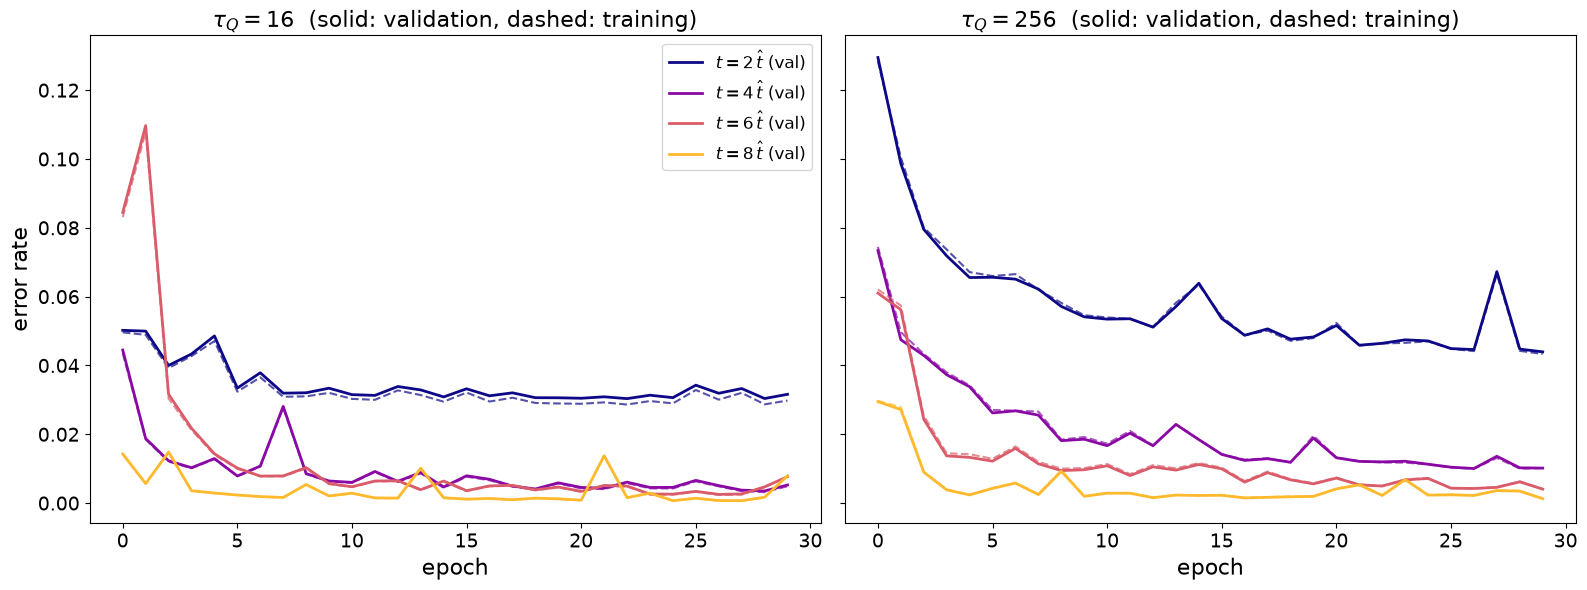

In [64]:
# ---- inputs ----
TAUS     = [8, 16, 32, 64, 128, 256]
T_CURVES = [2, 4, 6, 8]                # times shown as learning curves
TAU_SHOW = [16, 256]                   # taus shown as learning curves
TARGET   = "y_end"
FONTSIZE = 16

# ---- summary table: best epoch, recent improvement, train/val gap ----
print(f"{'tau':>4} {'t':>3} {'best ep':>8} {'last-5 gain':>12} {'val err':>9} {'train err':>10}")
for tau in TAUS:
    for r in an.load_results(tau, target=TARGET):
        h = np.array(r["history"])                    # columns: train_loss, val_loss, train_acc, val_acc
        val_err, train_err = 1 - h[:, 3], 1 - h[:, 2]
        best_ep = int(np.argmin(val_err))
        gain    = (val_err[-6] - val_err[-1]) / val_err[-6]    # relative drop over the last 5 epochs
        print(f"{tau:>4} {r['t_used']:>3g} {best_ep:>5}/{len(h) - 1} {100 * gain:>10.1f}% "
              f"{val_err[-1]:>9.4f} {train_err[-1]:>10.4f}")
    print()

# ---- learning curves ----
colors = plt.cm.plasma(np.linspace(0, 0.85, len(T_CURVES)))
fig, axes = plt.subplots(1, len(TAU_SHOW), figsize=(8 * len(TAU_SHOW), 6), squeeze=False, sharey=True)
for ax, tau in zip(axes[0], TAU_SHOW):
    res = {r["t_used"]: r for r in an.load_results(tau, target=TARGET)}
    for t, c in zip(T_CURVES, colors):
        h = np.array(res[t]["history"])
        ep = np.arange(len(h))
        ax.plot(ep, 1 - h[:, 3], "-",  color=c, lw=2, label=rf"$t = {t}\,\hat t$ (val)")
        ax.plot(ep, 1 - h[:, 2], "--", color=c, lw=1.5, alpha=0.7)
    ax.set_title(rf"$\tau_Q = {tau}$  (solid: validation, dashed: training)", fontsize=FONTSIZE)
    ax.set_xlabel("epoch", fontsize=FONTSIZE)
    ax.tick_params(labelsize=FONTSIZE - 2)
axes[0, 0].set_ylabel("error rate", fontsize=FONTSIZE)
axes[0, 0].legend(fontsize=FONTSIZE - 4)
plt.tight_layout()
plt.savefig("../figures/2d/learning_curves.png", dpi=150)
plt.show()